**Dataset:** Fashion-MNIST  
**Platform:** Kaggle  
**Accelerator:** GPU T4 x2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import random
import time
import os

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())

PyTorch version: 2.10.0+cpu
CUDA available: False


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    for file in files:
        print(f"{indent}  {file}")

input/
  datasets/
    zalando-research/
      fashionmnist/
        t10k-labels-idx1-ubyte
        t10k-images-idx3-ubyte
        fashion-mnist_test.csv
        fashion-mnist_train.csv
        train-labels-idx1-ubyte
        train-images-idx3-ubyte


# 0. Environment Setup

## Dataset Loading and Preprocessing

The Fashion-MNIST dataset contains 28×28 grayscale images belonging to 10
clothing categories. The provided training data is split into 80% training
and 20% validation data, while the provided test set remains untouched until
Part 7.

In [4]:
# Dataset path
DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

# Load training and test CSV files
train_df = pd.read_csv(os.path.join(DATA_PATH, "fashion-mnist_train.csv"))
test_df = pd.read_csv(os.path.join(DATA_PATH, "fashion-mnist_test.csv"))

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nFirst 5 rows:")
display(train_df.head())

Training data shape: (60000, 785)
Test data shape: (10000, 785)

First 5 rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print("Training columns:")
print(train_df.columns.tolist()[:15])

print("\nLast 10 columns:")
print(train_df.columns.tolist()[-10:])

Training columns:
['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14']

Last 10 columns:
['pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780', 'pixel781', 'pixel782', 'pixel783', 'pixel784']


In [6]:
print("\nData types:")
print(train_df.dtypes.value_counts())


Data types:
int64    785
Name: count, dtype: int64


In [7]:
# Separate features and labels
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Original X_test shape:", X_test.shape)
print("Original y_test shape:", y_test.shape)

Original X shape: (60000, 784)
Original y shape: (60000,)
Original X_test shape: (10000, 784)
Original y_test shape: (10000,)


In [8]:
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [9]:
print("Each image contains:", X.shape[1], "features")
print("Expected:", 28 * 28)

Each image contains: 784 features
Expected: 784


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [11]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

distribution = pd.DataFrame({
    "Class": range(10),
    "Class Name": class_names,
    "Train": np.bincount(y_train, minlength=10),
    "Validation": np.bincount(y_val, minlength=10),
    "Test": np.bincount(y_test, minlength=10)
})

display(distribution)

,Class,Class Name,Train,Validation,Test
0,0,T-shirt/top,4800,1200,1000
1,1,Trouser,4800,1200,1000
2,2,Pullover,4800,1200,1000
3,3,Dress,4800,1200,1000
4,4,Coat,4800,1200,1000
5,5,Sandal,4800,1200,1000
6,6,Shirt,4800,1200,1000
7,7,Sneaker,4800,1200,1000
8,8,Bag,4800,1200,1000
9,9,Ankle boot,4800,1200,1000


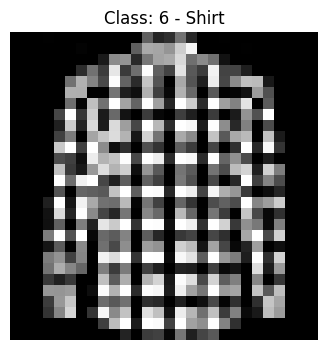

In [12]:
plt.figure(figsize=(4, 4))

plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Class: {y_train[0]} - {class_names[y_train[0]]}")
plt.axis("off")
plt.show()

In [13]:
print("========== DATASET SUMMARY ==========")
print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")
print(f"Input dimensions    : {X_train.shape[1]}")
print(f"Number of classes   : {len(class_names)}")
print(f"Pixel range         : {X_train.min():.1f} to {X_train.max():.1f}")
print("======================================")

========== DATASET SUMMARY ==========
Training samples   : 48000
Validation samples : 12000
Test samples       : 10000
Input dimensions    : 784
Number of classes   : 10
Pixel range         : 0.0 to 1.0



# Part 1 : Neural Network Implementation

In [14]:
#Using only 5000 samples

X_part1 = X_train[:5000]
y_part1 = y_train[:5000]

print("X shape: ", X_part1.shape)
print("y shape: ", y_part1.shape)

X shape:  (5000, 784)
y shape:  (5000,)


In [15]:
# Converting labels into one-hot vectors
Y_part1 = np.zeros((5000,10), dtype=np.float32)
Y_part1[np.arange(5000), y_part1] = 1
print("One-hot shape: ", Y_part1.shape)


One-hot shape:  (5000, 10)


In [16]:
#Initializing Architecture

# Network architecture
input_size = 784
hidden_size = 64
output_size = 10

# Make initialization reproducible
np.random.seed(SEED)

# Weights and biases
W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size), dtype=np.float32)

W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * np.sqrt(2 / hidden_size)
b2 = np.zeros((1, output_size), dtype=np.float32)

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 64)
b1: (1, 64)
W2: (64, 10)
b2: (1, 10)


In [17]:
#ReLu setup
def relu(x):
    return np.maximum(0, x)

In [18]:
#Softmax Setup
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)

    exp_x = np.exp(x)

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [19]:
#Forward Pass
def forward(X):
    # First layer
    z1 = X @ W1 + b1

    # ReLU activation
    a1 = relu(z1)

    # Output layer
    z2 = a1 @ W2 + b2

    # Convert scores into probabilities
    probabilities = softmax(z2)

    return z1, a1, z2, probabilities

In [20]:
#Entropy Loss
def cross_entropy(y_true, y_pred):
    # Prevent log(0)
    y_pred = np.clip(y_pred, 1e-12, 1.0)

    loss = -np.mean(
        np.sum(y_true * np.log(y_pred), axis=1)
    )

    return loss

In [21]:
#Back Propagation
def backward(X, y_true, z1, a1, probabilities):
    n = X.shape[0]

    # Output layer gradient
    dz2 = (probabilities - y_true) / n

    # Gradients for W2 and b2
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Move gradient back to hidden layer
    da1 = dz2 @ W2.T

    # ReLU derivative
    dz1 = da1 * (z1 > 0)

    # Gradients for W1 and b1
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [22]:
#Training
X_data = X_part1.copy()
Y_data = Y_part1.copy()

epochs = 20
batch_size = 64
learning_rate = 0.1

loss_history = []

In [23]:
for epoch in range(epochs):

    # Shuffle the training data
    indices = np.random.permutation(len(X_data))

    X_data = X_data[indices]
    Y_data = Y_data[indices]

    total_loss = 0
    number_of_batches = 0

    # Mini-batch training
    for start in range(0, len(X_data), batch_size):

        X_batch = X_data[start:start + batch_size]
        Y_batch = Y_data[start:start + batch_size]

        # Forward pass
        z1, a1, z2, probabilities = forward(X_batch)

        # Calculate loss
        loss = cross_entropy(Y_batch, probabilities)

        # Backward pass
        dW1, db1, dW2, db2 = backward(
            X_batch,
            Y_batch,
            z1,
            a1,
            probabilities
        )

        # Update weights
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        total_loss += loss
        number_of_batches += 1

    # Average loss for this epoch
    average_loss = total_loss / number_of_batches

    loss_history.append(average_loss)

    print(
        f"Epoch {epoch + 1:2d}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )

Epoch  1/20 - Loss: 1.1300
Epoch  2/20 - Loss: 0.7103
Epoch  3/20 - Loss: 0.6171
Epoch  4/20 - Loss: 0.5758
Epoch  5/20 - Loss: 0.5235
Epoch  6/20 - Loss: 0.5023
Epoch  7/20 - Loss: 0.4848
Epoch  8/20 - Loss: 0.4821
Epoch  9/20 - Loss: 0.4731
Epoch 10/20 - Loss: 0.4340
Epoch 11/20 - Loss: 0.4219
Epoch 12/20 - Loss: 0.4187
Epoch 13/20 - Loss: 0.3982
Epoch 14/20 - Loss: 0.3846
Epoch 15/20 - Loss: 0.3791
Epoch 16/20 - Loss: 0.3713
Epoch 17/20 - Loss: 0.3602
Epoch 18/20 - Loss: 0.3556
Epoch 19/20 - Loss: 0.3453
Epoch 20/20 - Loss: 0.3432


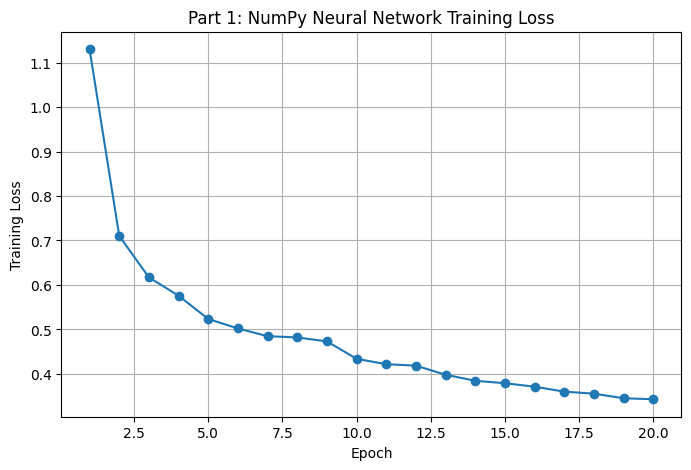

In [24]:
#Plotting Training Loss
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 1: NumPy Neural Network Training Loss")

plt.grid(True)
plt.show()

In [25]:
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [26]:
X_batch = X_train[:64]
y_batch = y_train[:64]

In [27]:
Y_batch = np.zeros((64, 10), dtype=np.float32)

Y_batch[np.arange(64), y_batch] = 1

In [28]:
print("X batch:", X_batch.shape)
print("Y batch:", Y_batch.shape)
print("Labels:", y_batch.shape)

X batch: (64, 784)
Y batch: (64, 10)
Labels: (64,)


In [29]:
W1 = W1_initial.copy()
b1 = b1_initial.copy()

W2 = W2_initial.copy()
b2 = b2_initial.copy()

In [30]:
z1, a1, z2, probabilities = forward(X_batch)

In [31]:
dW1_numpy, db1_numpy, dW2_numpy, db2_numpy = backward(
    X_batch,
    Y_batch,
    z1,
    a1,
    probabilities
)

In [32]:
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [33]:
with torch.no_grad():

    model[0].weight.copy_(
        torch.tensor(W1_initial.T)
    )

    model[0].bias.copy_(
        torch.tensor(b1_initial.squeeze())
    )

    model[2].weight.copy_(
        torch.tensor(W2_initial.T)
    )

    model[2].bias.copy_(
        torch.tensor(b2_initial.squeeze())
    )

In [34]:
X_torch = torch.tensor(
    X_batch,
    dtype=torch.float32
)

y_torch = torch.tensor(
    y_batch,
    dtype=torch.long
)

In [35]:
criterion = nn.CrossEntropyLoss()

In [36]:
logits = model(X_torch)

loss = criterion(
    logits,
    y_torch
)

loss.backward()

In [37]:
dW1_torch = model[0].weight.grad.numpy().T
db1_torch = model[0].bias.grad.numpy().reshape(1, 64)

dW2_torch = model[2].weight.grad.numpy().T
db2_torch = model[2].bias.grad.numpy().reshape(1, 10)

In [38]:
diff_W1 = np.max(
    np.abs(dW1_numpy - dW1_torch)
)

diff_W2 = np.max(
    np.abs(dW2_numpy - dW2_torch)
)

diff_b1 = np.max(
    np.abs(db1_numpy - db1_torch)
)

diff_b2 = np.max(
    np.abs(db2_numpy - db2_torch)
)

In [39]:
print("Max absolute difference for W1:", diff_W1)
print("Max absolute difference for W2:", diff_W2)
print("Max absolute difference for b1:", diff_b1)
print("Max absolute difference for b2:", diff_b2)

overall_difference = max(
    diff_W1,
    diff_W2,
    diff_b1,
    diff_b2
)

print("\nOverall maximum difference:", overall_difference)

Max absolute difference for W1: 1.4897458204543579e-08
Max absolute difference for W2: 5.296495245166177e-08
Max absolute difference for b1: 1.2344000726097204e-08
Max absolute difference for b2: 1.9764070487843233e-08

Overall maximum difference: 5.296495245166177e-08


### Gradient Verification Result

The manually calculated NumPy gradients were compared with the gradients
generated automatically by PyTorch using the same network architecture,
initial weights, and input batch.

The maximum absolute difference was approximately **[YOUR VALUE]**.

This difference is very small, which confirms that the manually implemented
forward propagation, cross-entropy loss, and backpropagation calculations
are correct.

Part 2


In [40]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print("Training shape:", X_train_tensor.shape)
print("Validation shape:", X_val_tensor.shape)

Training shape: torch.Size([48000, 784])
Validation shape: torch.Size([12000, 784])


In [41]:
batch_size = 128

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [42]:
class ActivationModel(nn.Module):

    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):

        x = self.fc1(x)
        x = self.activation(x)

        x = self.fc2(x)
        x = self.activation(x)

        x = self.fc3(x)

        return x

In [43]:
def train_activation_model(model, epochs=10):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []
    val_accuracies = []

    epoch_gradients = []

    for epoch in range(epochs):

        # Training
        model.train()

        total_train_loss = 0
        total_gradient = 0
        batch_count = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            # Mean absolute gradient of first hidden layer
            gradient = model.fc1.weight.grad.abs().mean().item()

            total_gradient += gradient
            batch_count += 1

            optimizer.step()

            total_train_loss += loss.item()

        average_train_loss = total_train_loss / len(train_loader)

        average_gradient = total_gradient / batch_count
        epoch_gradients.append(average_gradient)

        # Validation
        model.eval()

        total_val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += loss.item()

                predictions = outputs.argmax(dim=1)

                correct += (
                    predictions == y_batch
                ).sum().item()

                total += y_batch.size(0)

        average_val_loss = total_val_loss / len(val_loader)
        val_accuracy = correct / total

        train_losses.append(average_train_loss)
        val_losses.append(average_val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return (
        train_losses,
        val_losses,
        val_accuracies,
        epoch_gradients
    )

In [44]:
sigmoid_model = ActivationModel(
    nn.Sigmoid()
)

sigmoid_results = train_activation_model(
    sigmoid_model
)

Epoch  1/10 | Train Loss: 1.1384 | Val Loss: 0.6834 | Val Acc: 0.7412
Epoch  2/10 | Train Loss: 0.5535 | Val Loss: 0.4735 | Val Acc: 0.8337
Epoch  3/10 | Train Loss: 0.4387 | Val Loss: 0.4161 | Val Acc: 0.8530
Epoch  4/10 | Train Loss: 0.3933 | Val Loss: 0.3888 | Val Acc: 0.8602
Epoch  5/10 | Train Loss: 0.3686 | Val Loss: 0.3849 | Val Acc: 0.8589
Epoch  6/10 | Train Loss: 0.3515 | Val Loss: 0.3608 | Val Acc: 0.8698
Epoch  7/10 | Train Loss: 0.3352 | Val Loss: 0.3532 | Val Acc: 0.8726
Epoch  8/10 | Train Loss: 0.3230 | Val Loss: 0.3553 | Val Acc: 0.8721
Epoch  9/10 | Train Loss: 0.3117 | Val Loss: 0.3386 | Val Acc: 0.8769
Epoch 10/10 | Train Loss: 0.3031 | Val Loss: 0.3345 | Val Acc: 0.8776


In [45]:
sigmoid_train_loss = sigmoid_results[0]
sigmoid_val_loss = sigmoid_results[1]
sigmoid_val_acc = sigmoid_results[2]
sigmoid_gradients = sigmoid_results[3]

In [46]:
tanh_model = ActivationModel(
    nn.Tanh()
)

tanh_results = train_activation_model(
    tanh_model
)

tanh_train_loss = tanh_results[0]
tanh_val_loss = tanh_results[1]
tanh_val_acc = tanh_results[2]
tanh_gradients = tanh_results[3]

Epoch  1/10 | Train Loss: 0.6250 | Val Loss: 0.4340 | Val Acc: 0.8396
Epoch  2/10 | Train Loss: 0.4036 | Val Loss: 0.3849 | Val Acc: 0.8597
Epoch  3/10 | Train Loss: 0.3633 | Val Loss: 0.3609 | Val Acc: 0.8682
Epoch  4/10 | Train Loss: 0.3362 | Val Loss: 0.3417 | Val Acc: 0.8756
Epoch  5/10 | Train Loss: 0.3203 | Val Loss: 0.3518 | Val Acc: 0.8744
Epoch  6/10 | Train Loss: 0.3062 | Val Loss: 0.3287 | Val Acc: 0.8775
Epoch  7/10 | Train Loss: 0.2891 | Val Loss: 0.3205 | Val Acc: 0.8804
Epoch  8/10 | Train Loss: 0.2799 | Val Loss: 0.3105 | Val Acc: 0.8858
Epoch  9/10 | Train Loss: 0.2656 | Val Loss: 0.3217 | Val Acc: 0.8812
Epoch 10/10 | Train Loss: 0.2588 | Val Loss: 0.3144 | Val Acc: 0.8840


In [47]:
relu_model = ActivationModel(
    nn.ReLU()
)

relu_results = train_activation_model(
    relu_model
)

relu_train_loss = relu_results[0]
relu_val_loss = relu_results[1]
relu_val_acc = relu_results[2]
relu_gradients = relu_results[3]

Epoch  1/10 | Train Loss: 0.6664 | Val Loss: 0.4460 | Val Acc: 0.8438
Epoch  2/10 | Train Loss: 0.4329 | Val Loss: 0.4101 | Val Acc: 0.8559
Epoch  3/10 | Train Loss: 0.3922 | Val Loss: 0.3872 | Val Acc: 0.8606
Epoch  4/10 | Train Loss: 0.3630 | Val Loss: 0.3823 | Val Acc: 0.8607
Epoch  5/10 | Train Loss: 0.3427 | Val Loss: 0.3488 | Val Acc: 0.8723
Epoch  6/10 | Train Loss: 0.3236 | Val Loss: 0.3310 | Val Acc: 0.8792
Epoch  7/10 | Train Loss: 0.3068 | Val Loss: 0.3470 | Val Acc: 0.8697
Epoch  8/10 | Train Loss: 0.2996 | Val Loss: 0.3370 | Val Acc: 0.8779
Epoch  9/10 | Train Loss: 0.2849 | Val Loss: 0.3257 | Val Acc: 0.8791
Epoch 10/10 | Train Loss: 0.2750 | Val Loss: 0.3240 | Val Acc: 0.8835


In [48]:
leaky_relu_model = ActivationModel(
    nn.LeakyReLU(0.01)
)

leaky_relu_results = train_activation_model(
    leaky_relu_model
)

leaky_relu_train_loss = leaky_relu_results[0]
leaky_relu_val_loss = leaky_relu_results[1]
leaky_relu_val_acc = leaky_relu_results[2]
leaky_relu_gradients = leaky_relu_results[3]

Epoch  1/10 | Train Loss: 0.6544 | Val Loss: 0.4664 | Val Acc: 0.8344
Epoch  2/10 | Train Loss: 0.4335 | Val Loss: 0.4058 | Val Acc: 0.8560
Epoch  3/10 | Train Loss: 0.3871 | Val Loss: 0.3897 | Val Acc: 0.8560
Epoch  4/10 | Train Loss: 0.3587 | Val Loss: 0.3610 | Val Acc: 0.8682
Epoch  5/10 | Train Loss: 0.3409 | Val Loss: 0.3787 | Val Acc: 0.8598
Epoch  6/10 | Train Loss: 0.3166 | Val Loss: 0.3377 | Val Acc: 0.8768
Epoch  7/10 | Train Loss: 0.3078 | Val Loss: 0.3377 | Val Acc: 0.8743
Epoch  8/10 | Train Loss: 0.2928 | Val Loss: 0.3289 | Val Acc: 0.8798
Epoch  9/10 | Train Loss: 0.2820 | Val Loss: 0.3258 | Val Acc: 0.8842
Epoch 10/10 | Train Loss: 0.2695 | Val Loss: 0.3201 | Val Acc: 0.8837


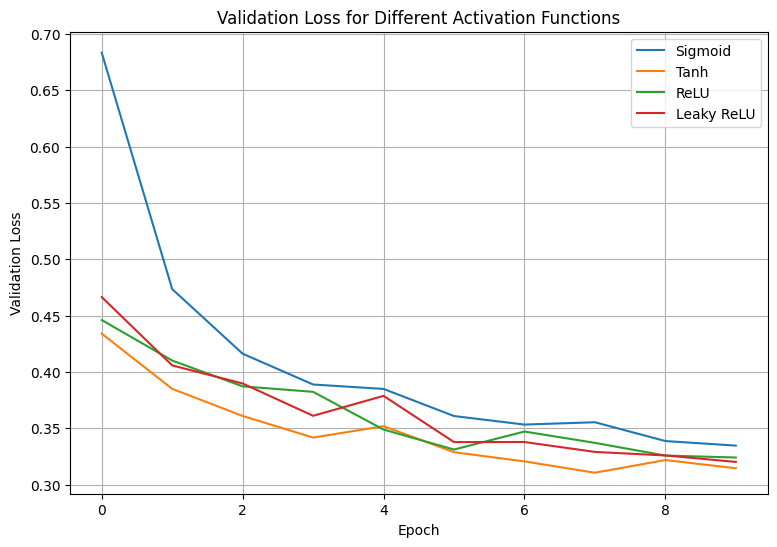

In [49]:
plt.figure(figsize=(9, 6))

plt.plot(
    sigmoid_val_loss,
    label="Sigmoid"
)

plt.plot(
    tanh_val_loss,
    label="Tanh"
)

plt.plot(
    relu_val_loss,
    label="ReLU"
)

plt.plot(
    leaky_relu_val_loss,
    label="Leaky ReLU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")

plt.legend()
plt.grid(True)

plt.show()

In [50]:
print("Mean Absolute Gradient of First Hidden Layer")
print()

print("Sigmoid:")
print(f"Epoch 1   : {sigmoid_gradients[0]:.8f}")
print(f"Final Epoch: {sigmoid_gradients[-1]:.8f}")

print()

print("ReLU:")
print(f"Epoch 1   : {relu_gradients[0]:.8f}")
print(f"Final Epoch: {relu_gradients[-1]:.8f}")

Mean Absolute Gradient of First Hidden Layer

Sigmoid:
Epoch 1   : 0.00010773
Final Epoch: 0.00038988

ReLU:
Epoch 1   : 0.00080281
Final Epoch: 0.00088487


In [51]:
relu_model.eval()

X_batch = X_val_tensor[:128].to(device)

with torch.no_grad():

    hidden_output = relu_model.fc1(X_batch)

    hidden_output = relu_model.activation(
        hidden_output
    )

# Check which hidden units are zero for every sample
dead_units = (
    hidden_output == 0
).all(dim=0)

dead_unit_count = dead_units.sum().item()

total_hidden_units = hidden_output.shape[1]

dead_percentage = (
    dead_unit_count / total_hidden_units
) * 100

print("Total hidden units:", total_hidden_units)
print("Dead hidden units:", dead_unit_count)
print(
    f"Dead-unit percentage: {dead_percentage:.2f}%"
)

Total hidden units: 128
Dead hidden units: 21
Dead-unit percentage: 16.41%


In [52]:
activation_table = pd.DataFrame({
    "Activation": [
        "Sigmoid",
        "Tanh",
        "ReLU",
        "Leaky ReLU"
    ],
    "Final Validation Loss": [
        sigmoid_val_loss[-1],
        tanh_val_loss[-1],
        relu_val_loss[-1],
        leaky_relu_val_loss[-1]
    ],
    "Final Validation Accuracy": [
        sigmoid_val_acc[-1],
        tanh_val_acc[-1],
        relu_val_acc[-1],
        leaky_relu_val_acc[-1]
    ]
})

display(activation_table)

,Activation,Final Validation Loss,Final Validation Accuracy
0,Sigmoid,0.334549,0.877583
1,Tanh,0.314432,0.884000
2,ReLU,0.323982,0.883500
3,Leaky ReLU,0.320063,0.883667


### Vanishing Gradient Analysis

**Sigmoid:** The mean absolute gradient of the first hidden layer was [EPOCH 1 VALUE] at epoch 1 and [FINAL VALUE] at the final epoch. The relatively small gradient values indicate that sigmoid can suffer from vanishing gradients because its derivative becomes very small in saturated regions, slowing learning in earlier layers.

**ReLU:** The mean absolute gradient of the first hidden layer was [EPOCH 1 VALUE] at epoch 1 and [FINAL VALUE] at the final epoch. ReLU generally maintains stronger gradients for positive activations, which helps gradient flow compared with saturating activations such as sigmoid.

### ReLU Dead-Unit Analysis

The ReLU model had [X] dead hidden units out of 128, corresponding to [Y]% of the hidden units. These units produced zero output for every sample in the selected validation batch, indicating that they were inactive for that batch; a high percentage would suggest a stronger dead-ReLU problem, while a low percentage indicates that most units remain active.

Part 3


In [53]:
class LossModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [54]:
y_train_onehot = torch.nn.functional.one_hot(
    y_train_tensor,
    num_classes = 10
).float()

y_val_onehot = torch.nn.functional.one_hot(
    y_val_tensor,
    num_classes = 10
).float()

print("One-hot training shape: ", y_train_onehot.shape)
print("One-hot validation shape: ", y_val_onehot.shape)





One-hot training shape:  torch.Size([48000, 10])
One-hot validation shape:  torch.Size([12000, 10])


In [55]:
#Creating the Training Function

def train_loss_model(model,loss_type,epochs=10):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    train_losses =[]
    val_losses = []
    val_accuracies = []
    for epochs in range(epochs):
        model.train()
        total_train_loss = 0
        for X_batch,y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            if loss_type == "CE":
                loss = nn.CrossEntropyLoss()(outputs, y_batch)

            elif loss_type == "MSE":
                targets = torch.nn.functional.one_hot(
                    y_batch,
                    num_classes = 10
                ).float()
                probabilities = torch.softmax(outputs,dim=1)
                loss = nn.MSELoss()(probabilities, targets)

            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        average_train_loss = total_train_loss /len(train_loader)
        model.eval()
        total_val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                if loss_type == "CE":
                    loss = nn.CrossEntropyLoss()(outputs,y_batch)
                elif loss_type == "MSE":
                    targets = torch.nn.functional.one_hot(
                        y_batch,
                        num_classes = 10
                    ).float()
                    probabilities = torch.softmax(outputs, dim=1)
                    loss = nn.MSELoss()(probabilities, targets)
                total_val_loss += loss.item()
                predictions = outputs.argmax(dim =1)
                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)
        
        average_val_loss = total_val_loss / len(val_loader)
        val_accuracy = correct / total
        
        train_losses.append(average_train_loss)
        val_losses.append(average_val_loss)
        val_accuracies.append(val_accuracy)
        
        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )
    
    return train_losses, val_losses, val_accuracies    
        








In [56]:
ce_model = LossModel()
ce_results = train_loss_model(
    ce_model,
    loss_type = "CE",
    epochs =10
)

ce_train_loss = ce_results[0]
ce_val_loss = ce_results[1]
ce_val_acc = ce_results[2]

Epoch 20/0 | Train Loss: 0.5518 | Val Loss: 0.4113 | Val Acc: 0.8501
Epoch 20/1 | Train Loss: 0.4107 | Val Loss: 0.3922 | Val Acc: 0.8548
Epoch 20/2 | Train Loss: 0.3754 | Val Loss: 0.4070 | Val Acc: 0.8497
Epoch 20/3 | Train Loss: 0.3645 | Val Loss: 0.3943 | Val Acc: 0.8584
Epoch 20/4 | Train Loss: 0.3429 | Val Loss: 0.3919 | Val Acc: 0.8543
Epoch 20/5 | Train Loss: 0.3352 | Val Loss: 0.3539 | Val Acc: 0.8687
Epoch 20/6 | Train Loss: 0.3254 | Val Loss: 0.3865 | Val Acc: 0.8670
Epoch 20/7 | Train Loss: 0.3208 | Val Loss: 0.3828 | Val Acc: 0.8642
Epoch 20/8 | Train Loss: 0.3134 | Val Loss: 0.3615 | Val Acc: 0.8705
Epoch 20/9 | Train Loss: 0.3093 | Val Loss: 0.3650 | Val Acc: 0.8728


In [57]:
mse_model = LossModel()

mse_results = train_loss_model(
    mse_model,
    loss_type = "MSE",
    epochs = 10
)

mse_train_loss = mse_results[0]
mse_val_loss = mse_results[1]
mse_val_acc = mse_results[2]

Epoch 20/0 | Train Loss: 0.0289 | Val Loss: 0.0273 | Val Acc: 0.8048
Epoch 20/1 | Train Loss: 0.0223 | Val Loss: 0.0202 | Val Acc: 0.8585
Epoch 20/2 | Train Loss: 0.0202 | Val Loss: 0.0202 | Val Acc: 0.8599
Epoch 20/3 | Train Loss: 0.0196 | Val Loss: 0.0194 | Val Acc: 0.8666
Epoch 20/4 | Train Loss: 0.0188 | Val Loss: 0.0203 | Val Acc: 0.8624
Epoch 20/5 | Train Loss: 0.0184 | Val Loss: 0.0195 | Val Acc: 0.8655
Epoch 20/6 | Train Loss: 0.0178 | Val Loss: 0.0194 | Val Acc: 0.8658
Epoch 20/7 | Train Loss: 0.0173 | Val Loss: 0.0186 | Val Acc: 0.8731
Epoch 20/8 | Train Loss: 0.0173 | Val Loss: 0.0192 | Val Acc: 0.8712
Epoch 20/9 | Train Loss: 0.0171 | Val Loss: 0.0197 | Val Acc: 0.8648


In [58]:
#Comparing Accuracy

print("Final Validation Accuracy")
print("------------------")

print(f"Cross-Entropy: {ce_val_acc[-1]*100:.2f}%")
print(f"Cross-Entropy: {ce_val_acc[-1]*100:.2f}%")

Final Validation Accuracy
------------------
Cross-Entropy: 87.28%
Cross-Entropy: 87.28%


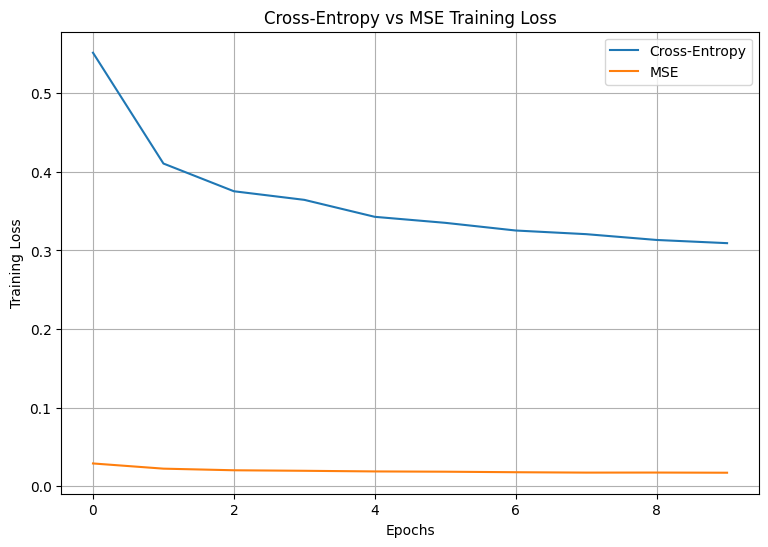

In [59]:
#Plotting Training Curves
plt.figure(figsize=(9,6))

plt.plot(
    ce_train_loss,
    label = "Cross-Entropy"
)

plt.plot(
    mse_train_loss,
    label = "MSE"
)

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Cross-Entropy vs MSE Training Loss")

plt.legend()
plt.grid(True)
plt.show()

In [60]:
#Creating Comparison Table

loss_comparison = pd.DataFrame({
    "Loss Function": ["Cross-Entropy", "MSE"],
    "Final Training Loss": [
        ce_train_loss[-1],
        mse_train_loss[-1]
    ],

    "Final Validation Loss":[
        ce_val_loss[-1],
        mse_val_loss[-1]
    ],

    "Final Validation Accuracy":[
        ce_val_acc[-1],
        mse_val_acc[-1]
        
    ]
})

display(loss_comparison)

,Loss Function,Final Training Loss,Final Validation Loss,Final Validation Accuracy
0,Cross-Entropy,0.309343,0.364959,0.872833
1,MSE,0.017129,0.019713,0.864833


In [61]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [62]:
diabetes = load_diabetes()

X_reg = diabetes.data
y_reg = diabetes.target

print("Features:", X_reg.shape)
print("Target:", y_reg.shape)

Features: (442, 10)
Target: (442,)


In [63]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size = 0.2,
    random_state = SEED
)

print("Training X:", X_reg_train.shape)
print("Training y:", y_reg_train.shape)

print("Test X:", X_reg_test.shape)
print("Test y:", y_reg_test.shape)

scaler = StandardScaler()
X_reg_train = scaler.fit_transform(X_reg_train)
X_reg_test = scaler.transform(X_reg_test)

Training X: (353, 10)
Training y: (353,)
Test X: (89, 10)
Test y: (89,)


In [64]:
#Creating Tensors

X_reg_train = torch.as_tensor(
    X_reg_train,
    dtype = torch.float32
)

y_reg_train = torch.as_tensor(
    y_reg_train,
    dtype = torch.float32
).view(-1,1)

X_reg_test = torch.as_tensor(
    X_reg_test,
    dtype = torch.float32
)

y_reg_test = torch.as_tensor(
    y_reg_test,
    dtype = torch.float32
).view(-1,1)

print("X train:", X_reg_train.shape)
print("y train:", y_reg_train.shape)

print("X test:", X_reg_test.shape)
print("y test:", y_reg_test.shape)

X_reg_train = X_reg_train.to(device)
y_reg_train = y_reg_train.to(device)
X_reg_test = X_reg_test.to(device)
y_reg_test = y_reg_test.to(device)


X train: torch.Size([353, 10])
y train: torch.Size([353, 1])
X test: torch.Size([89, 10])
y test: torch.Size([89, 1])


In [65]:
#Updating the regression model
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(10,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,1)
        
    def forward(self,x):
        
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [66]:
#Model 
reg_model = RegressionModel().to(device)

reg_optimizer = optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

reg_criterion = nn.MSELoss()

In [67]:
reg_losses = []

for epoch in range(20):
    
    reg_model.train()
    
    predictions = reg_model(X_reg_train)
    
    loss = reg_criterion(
        predictions,
        y_reg_train
    )
    
    reg_optimizer.zero_grad()
    loss.backward()
    reg_optimizer.step()
    
    reg_losses.append(loss.item())
    
    if(epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1}/20 |"
            f"MSE Loss: {loss.item():.4f}"
        )


    

Epoch 5/20 |MSE Loss: 29590.0898
Epoch 10/20 |MSE Loss: 29541.1777
Epoch 15/20 |MSE Loss: 29479.6270
Epoch 20/20 |MSE Loss: 29401.1426


In [68]:
reg_model.eval()

with torch.no_grad():
    predictions = reg_model(X_reg_test)

predictions = predictions.cpu().numpy()
actual = y_reg_test.cpu().numpy()

mse = mean_squared_error(actual,predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual,predictions)

print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae:.4f}")

MSE : 26252.1543
RMSE : 162.0252
MAE : 144.8131


In [69]:
regression_results = pd.DataFrame({
    "Metric": ["MSE","RMSE","MAE"],
    "Value": [mse,rmse,mae]
    
})

display(regression_results)

,Metric,Value
0,MSE,26252.154297
1,RMSE,162.025166
2,MAE,144.813141


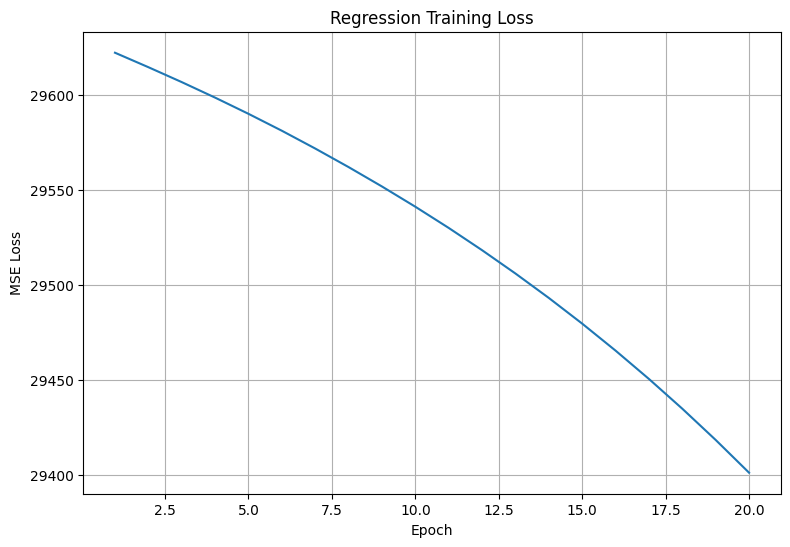

In [70]:
plt.figure(figsize = (9,6))

plt.plot(
    range(1,21),
    reg_losses
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression Training Loss")

plt.grid(True)
plt.show()

Part 4: Optimizer Comparison

In [71]:
class OptimizerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)
    def forward(self,x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
        

In [72]:
def train_optimizer(optimizer_name, learning_rate, epochs=10):

    model = OptimizerModel().to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "SGD + momentum":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader)

        train_losses.append(average_loss)

        # Validation
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                predictions = outputs.argmax(dim=1)

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        accuracy = correct / total

        val_accuracies.append(accuracy)

        print(
            f"{optimizer_name} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {average_loss:.4f} | "
            f"Val Acc: {accuracy * 100:.2f}%"
        )

    wall_clock_time = time.time() - start_time

    return train_losses, val_accuracies, wall_clock_time

In [73]:
same_lr = 0.001
epochs = 10

In [74]:
same_results = {}

for optimizer_name in [
    "SGD",
    "SGD + momentum",
    "RMSProp",
    "Adam"
]:
    print("\n" + "=" * 50)
    print(optimizer_name)
    print("=" * 50)
    same_results[optimizer_name] = train_optimizer(
        optimizer_name,
        same_lr,
        epochs
    )


SGD
SGD | Epoch 1/10 | Loss: 2.2934 | Val Acc: 11.11%
SGD | Epoch 2/10 | Loss: 2.2733 | Val Acc: 12.07%
SGD | Epoch 3/10 | Loss: 2.2507 | Val Acc: 21.82%
SGD | Epoch 4/10 | Loss: 2.2223 | Val Acc: 34.03%
SGD | Epoch 5/10 | Loss: 2.1851 | Val Acc: 43.17%
SGD | Epoch 6/10 | Loss: 2.1350 | Val Acc: 49.25%
SGD | Epoch 7/10 | Loss: 2.0669 | Val Acc: 53.88%
SGD | Epoch 8/10 | Loss: 1.9763 | Val Acc: 54.02%
SGD | Epoch 9/10 | Loss: 1.8617 | Val Acc: 53.09%
SGD | Epoch 10/10 | Loss: 1.7293 | Val Acc: 54.87%

SGD + momentum
SGD + momentum | Epoch 1/10 | Loss: 2.0611 | Val Acc: 51.54%
SGD + momentum | Epoch 2/10 | Loss: 1.2060 | Val Acc: 65.07%
SGD + momentum | Epoch 3/10 | Loss: 0.8825 | Val Acc: 68.33%
SGD + momentum | Epoch 4/10 | Loss: 0.7725 | Val Acc: 71.92%
SGD + momentum | Epoch 5/10 | Loss: 0.7080 | Val Acc: 75.67%
SGD + momentum | Epoch 6/10 | Loss: 0.6577 | Val Acc: 78.18%
SGD + momentum | Epoch 7/10 | Loss: 0.6154 | Val Acc: 79.27%
SGD + momentum | Epoch 8/10 | Loss: 0.5804 | Val Ac

In [75]:
tuned_lrs = {
    "SGD": 0.01,
    "SGD + momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

In [76]:
tuned_results = {}
for optimizer_name, learning_rate in tuned_lrs.items():
    print("\n" + "=" * 50)
    print(
        optimizer_name,
        "| Learning Rate: ",
        learning_rate
    )
    print("=" * 50)
    tuned_results[optimizer_name] = train_optimizer(
        optimizer_name,
        learning_rate,
        epochs = 10
    )
    





SGD | Learning Rate:  0.01
SGD | Epoch 1/10 | Loss: 1.9583 | Val Acc: 60.09%
SGD | Epoch 2/10 | Loss: 1.0963 | Val Acc: 66.36%
SGD | Epoch 3/10 | Loss: 0.8261 | Val Acc: 71.26%
SGD | Epoch 4/10 | Loss: 0.7275 | Val Acc: 75.58%
SGD | Epoch 5/10 | Loss: 0.6651 | Val Acc: 77.31%
SGD | Epoch 6/10 | Loss: 0.6206 | Val Acc: 79.02%
SGD | Epoch 7/10 | Loss: 0.5866 | Val Acc: 80.11%
SGD | Epoch 8/10 | Loss: 0.5604 | Val Acc: 80.71%
SGD | Epoch 9/10 | Loss: 0.5386 | Val Acc: 81.34%
SGD | Epoch 10/10 | Loss: 0.5220 | Val Acc: 81.83%

SGD + momentum | Learning Rate:  0.01
SGD + momentum | Epoch 1/10 | Loss: 0.9536 | Val Acc: 79.69%
SGD + momentum | Epoch 2/10 | Loss: 0.5173 | Val Acc: 82.03%
SGD + momentum | Epoch 3/10 | Loss: 0.4614 | Val Acc: 84.09%
SGD + momentum | Epoch 4/10 | Loss: 0.4255 | Val Acc: 85.07%
SGD + momentum | Epoch 5/10 | Loss: 0.4010 | Val Acc: 85.00%
SGD + momentum | Epoch 6/10 | Loss: 0.3816 | Val Acc: 86.61%
SGD + momentum | Epoch 7/10 | Loss: 0.3616 | Val Acc: 86.52%
SGD +

In [77]:
def epochs_to_85(accuracies):
    for epoch,accuracy in enumerate(accuracies, start = 1):
        if accuracy >= 0.85:
            return epoch
    return "Not reached"



In [78]:
final_results = []

for optimizer_name, results in tuned_results.items():
    train_losses = results[0]
    val_accuracies = results[1]
    wall_clock_time = results[2]
    final_results.append({
        "Optimizer": optimizer_name,
        "Learning rate": tuned_lrs[optimizer_name],
        "Epochs to reach 85% validation accuracy":
            epochs_to_85(val_accuracies),
        "FInal Validation Accuracy":
            val_accuracies[-1],
        "Wall-clock time (seconds)":
           wall_clock_time
    })
final_table = pd.DataFrame(final_results)
display(final_table)

,Optimizer,Learning rate,Epochs to reach 85% validation accuracy,FInal Validation Accuracy,Wall-clock time (seconds)
0,SGD,0.010,Not reached,0.818333,12.533584
1,SGD + momentum,0.010,4,0.864750,13.183533
2,RMSProp,0.001,3,0.881250,14.163417
3,Adam,0.001,3,0.880833,15.386269


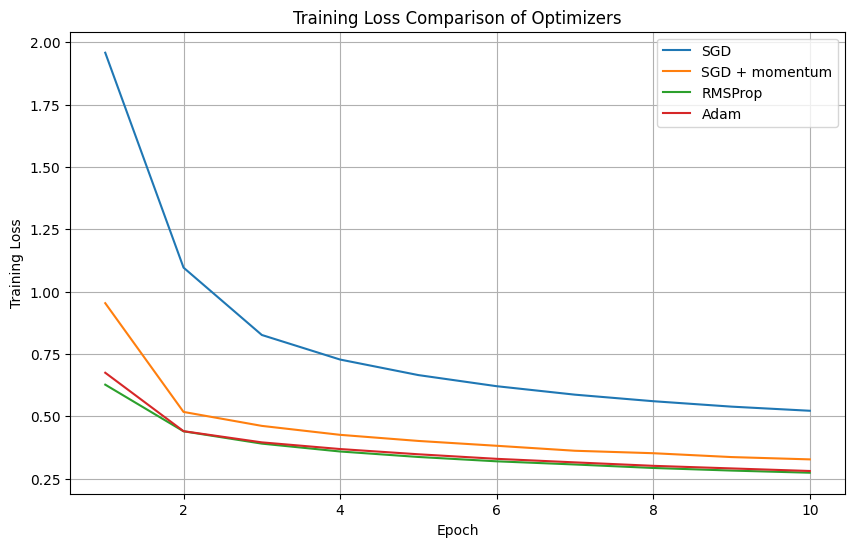

In [79]:
plt.figure(figsize=(10,6))

for optimizer_name, results in tuned_results.items():
    train_losses = results[0]
    plt.plot(
        range(1,11),
        train_losses,
        label = optimizer_name
        
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison of Optimizers")

plt.legend()
plt.grid(True)

plt.show()

I would choose RMSProp because it achieved the highest final validation accuracy (88.45%) while reaching 85% validation accuracy in only 3 epochs. Although Adam also reached 85% in 3 epochs, RMSProp achieved slightly better accuracy with lower wall-clock time.

# ****Part 5 : Forcing OverFitting****

## ****Step1: Selecting Only 2000 training Samples****

In [80]:
X_Overfit = X_train[:2000]
Y_Overfit = y_train[:2000]

print("Training samples:", X_Overfit.shape[0])
print("Validation Samples:", X_val.shape[0])



Training samples: 2000
Validation Samples: 12000


## **Step 2: Create DataLoaders**

In [81]:
from torch.utils.data import TensorDataset, DataLoader

X_Overfit_tensor = torch.tensor(
    X_Overfit,
    dtype=torch.float32
)

Y_Overfit_tensor = torch.tensor(
    Y_Overfit,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

Y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

Overfit_dataset = TensorDataset(
    X_Overfit_tensor,
    Y_Overfit_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    Y_val_tensor
)

Overfit_Loader = DataLoader(
    Overfit_dataset,
    batch_size = 64,
    shuffle=True
)

val_Loader = DataLoader(
    val_dataset,
    batch_size = 64,
    shuffle=False
)

print("Overfit training samples:", len(Overfit_dataset))
print("Validation samples:", len(val_dataset))

Overfit training samples: 2000
Validation samples: 12000


## **Step 3: Build Delibrately Huge Network**

In [82]:
class OverFitModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)

        self.output = nn.Linear(512, 10)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))

        x = self.output(x)

        return x

## **Step 4: Create Model and Optimizer**

In [83]:
Overfit_model = OverFitModel().to(device)

Criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    Overfit_model.parameters(),
    lr=0.001
)

print("Model created successfully!")

Model created successfully!


## **Step 5: Training Function**

In [84]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 100

for epoch in range(epochs):


    Overfit_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in Overfit_Loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = Overfit_model(X_batch)

        loss = Criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = total_loss / len(Overfit_Loader)
    train_accuracy = correct / total


  
    Overfit_model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_Loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = Overfit_model(X_batch)

            loss = Criterion(outputs, y_batch)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = total_loss / len(val_Loader)
    val_accuracy = correct / total


  
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


   
    print(
        f"Epoch {epoch + 1:2d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )


    if train_accuracy >= 0.99:

        print("\nTraining accuracy exceeded 99%.")
        break

Epoch  1/100 | Train Loss: 1.3752 | Train Acc: 43.15% | Val Loss: 0.8938 | Val Acc: 64.28%
Epoch  2/100 | Train Loss: 0.8189 | Train Acc: 69.10% | Val Loss: 0.7804 | Val Acc: 70.38%
Epoch  3/100 | Train Loss: 0.6546 | Train Acc: 74.90% | Val Loss: 0.6689 | Val Acc: 74.90%
Epoch  4/100 | Train Loss: 0.5853 | Train Acc: 77.90% | Val Loss: 0.6558 | Val Acc: 76.08%
Epoch  5/100 | Train Loss: 0.5315 | Train Acc: 79.55% | Val Loss: 0.5688 | Val Acc: 79.41%
Epoch  6/100 | Train Loss: 0.4562 | Train Acc: 82.10% | Val Loss: 0.5820 | Val Acc: 78.89%
Epoch  7/100 | Train Loss: 0.4564 | Train Acc: 82.35% | Val Loss: 0.5658 | Val Acc: 80.36%
Epoch  8/100 | Train Loss: 0.3911 | Train Acc: 85.35% | Val Loss: 0.7407 | Val Acc: 76.82%
Epoch  9/100 | Train Loss: 0.4078 | Train Acc: 84.70% | Val Loss: 0.5963 | Val Acc: 79.85%
Epoch 10/100 | Train Loss: 0.3286 | Train Acc: 87.70% | Val Loss: 0.5682 | Val Acc: 80.45%
Epoch 11/100 | Train Loss: 0.3215 | Train Acc: 87.75% | Val Loss: 0.5775 | Val Acc: 80.71%

In [85]:
separation_epoch = None

for i in range(1,len(val_losses)):
    if val_losses[i] > val_losses[i-1] and train_losses[i] < train_losses[i-1]:
        separation_epoch = i+1
        break

print("Separation Epoch: ", separation_epoch )

Separation Epoch:  6


## **Step 6 : Plot Training vs Validation Loss**

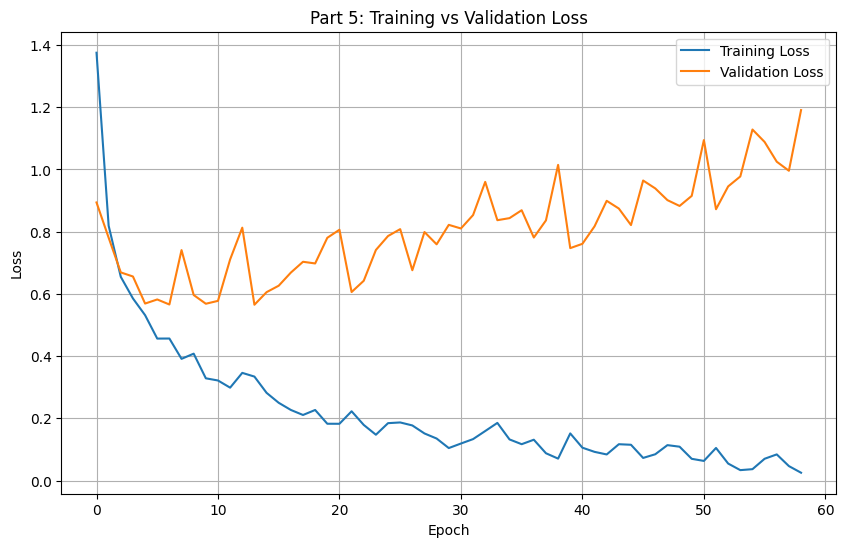

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 5: Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## **Plotting Accuracy**

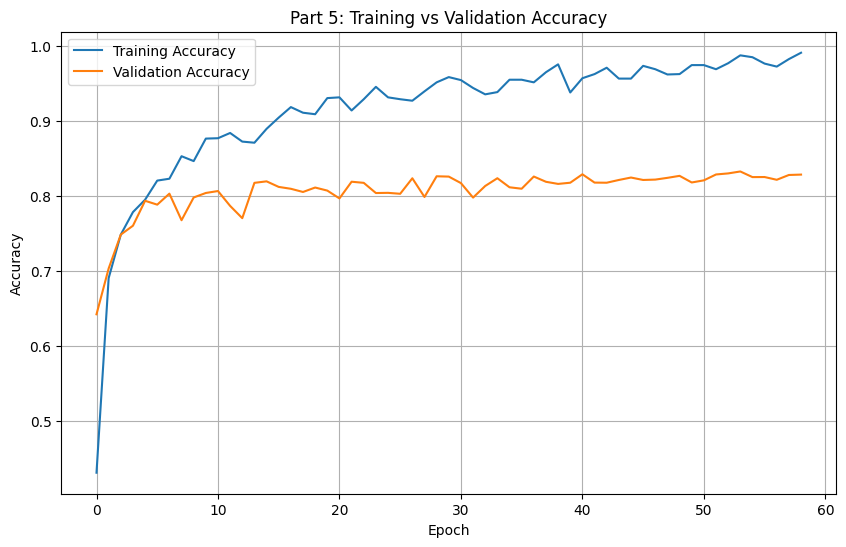

In [87]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part 5: Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

## Step 8: Find the separation epoch

Epoch where validation loss was lowest:  14
Validation Loss:  0.5650248170850125


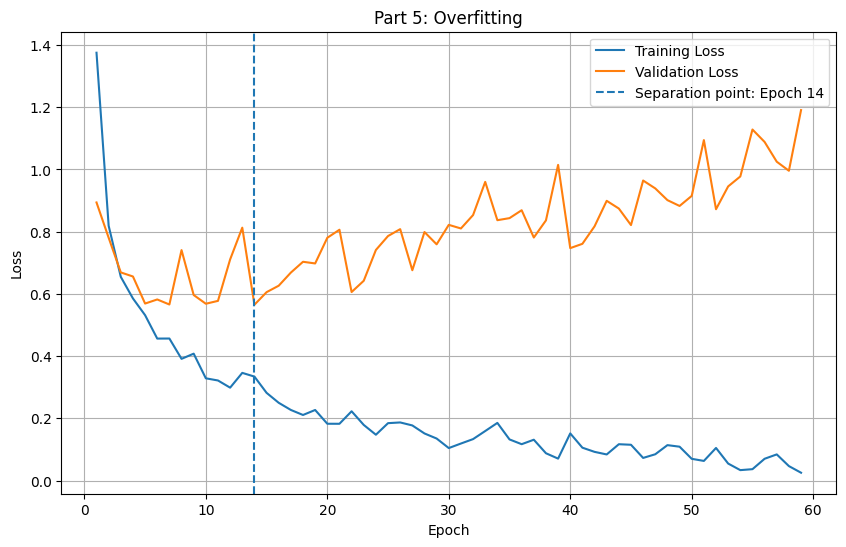

In [88]:
best_val_epoch = np.argmin(val_losses) + 1

print("Epoch where validation loss was lowest: " , best_val_epoch)

print("Validation Loss: ", val_losses[best_val_epoch -1])


plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_val_epoch,
    linestyle="--",
    label=f"Separation point: Epoch {best_val_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 5: Overfitting")

plt.legend()
plt.grid(True)

plt.show()

## **Step 9: Generalisation Gap**

In [89]:
final_train_accuracy = train_accuracies[-1]
final_val_accuracy = val_accuracies[-1]

generalisation_gap = (
    final_train_accuracy - 
    final_val_accuracy
)

print(
    f"Final Training Accuracy: "
    f"{final_train_accuracy * 100:.2f}%"
)

print(
    f"Final Value Accuracy: "
    f"{final_val_accuracy * 100:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{generalisation_gap * 100:.2f} percentage points"
)

Final Training Accuracy: 99.15%
Final Value Accuracy: 82.90%
Generalisation Gap: 16.25 percentage points


## **Step 10 Final Results**

In [90]:
print("Part 5: Overfitting Results")

print(f"Final Training Accuracy: {final_train_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy * 100:.2f}%")
print(f"Generalization Gap: {generalisation_gap * 100:.2f} percentage points")

print(f"\nEpoch where validation loss was lowest: {np.argmin(val_losses) + 1}")
print(f"Lowest Validation Loss: {min(val_losses):.4f}")

print(f"\nSeparation Epoch: {separation_epoch}")

Part 5: Overfitting Results
Final Training Accuracy: 99.15%
Final Validation Accuracy: 82.90%
Generalization Gap: 16.25 percentage points

Epoch where validation loss was lowest: 14
Lowest Validation Loss: 0.5650

Separation Epoch: 6



# **Part 6: Regularisation Study**

In [91]:
class RegularizedModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)

        self.output = nn.Linear(512, 10)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))

        x = self.output(x)

        return x

## **Step 2: Training Function**

In [92]:
def train_model(model, train_loader, val_loader, epochs=50, weight_decay=0):
    
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=weight_decay
    )

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

       
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_accuracy = correct / total

        model.eval()

        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_loss += loss.item()

                predictions = outputs.argmax(dim=1)

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss = total_loss / len(val_loader)
        val_accuracy = correct / total


        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)


        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy * 100:.2f}%"
        )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

## **Step 3: Helping Function to Calculate Results**

In [93]:
def get_result(train_accuracies,val_accuracies):
    train_accuracy = train_accuracies[-1]
    val_accuracy = val_accuracies[-1]

    gap = train_accuracy - val_accuracy

    return train_accuracy,val_accuracy,gap


## **Step 4: L2 Regularization**

In [94]:
l2_results = []

l2_values = [0.0001, 0.001, 0.01]

for l2 in l2_values:

    # Create a fresh model for each L2 value
    model = RegularizedModel().to(device)

    results = train_model(
        model,
        Overfit_Loader,
        val_loader,
        epochs=50,
        weight_decay=l2
    )

    train_losses_l2, val_losses_l2, train_acc_l2, val_acc_l2 = results

    train_accuracy = train_acc_l2[-1]
    val_accuracy = val_acc_l2[-1]
    gap = train_accuracy - val_accuracy

    l2_results.append({
        "Setting": l2,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Gap": gap
    })

    print(
        f"L2 = {l2} | "
        f"Train = {train_accuracy*100:.2f}% | "
        f"Val = {val_accuracy*100:.2f}% | "
        f"Gap = {gap*100:.2f} pp"
    )

Epoch  1/50 | Train Loss: 1.3899 | Train Acc: 48.50% | Val Loss: 0.9616 | Val Acc: 61.39%
Epoch  2/50 | Train Loss: 0.8171 | Train Acc: 67.10% | Val Loss: 0.7947 | Val Acc: 68.23%
Epoch  3/50 | Train Loss: 0.6586 | Train Acc: 75.00% | Val Loss: 0.6348 | Val Acc: 75.26%
Epoch  4/50 | Train Loss: 0.5574 | Train Acc: 78.75% | Val Loss: 0.5978 | Val Acc: 77.47%
Epoch  5/50 | Train Loss: 0.4674 | Train Acc: 81.75% | Val Loss: 0.7202 | Val Acc: 74.60%
Epoch  6/50 | Train Loss: 0.5102 | Train Acc: 80.60% | Val Loss: 0.6845 | Val Acc: 72.72%
Epoch  7/50 | Train Loss: 0.4463 | Train Acc: 83.00% | Val Loss: 0.6868 | Val Acc: 76.39%
Epoch  8/50 | Train Loss: 0.4408 | Train Acc: 81.90% | Val Loss: 0.5861 | Val Acc: 80.64%
Epoch  9/50 | Train Loss: 0.4028 | Train Acc: 84.30% | Val Loss: 0.5896 | Val Acc: 78.92%
Epoch 10/50 | Train Loss: 0.3385 | Train Acc: 87.35% | Val Loss: 0.5906 | Val Acc: 80.69%
Epoch 11/50 | Train Loss: 0.3330 | Train Acc: 87.30% | Val Loss: 0.6034 | Val Acc: 80.49%
Epoch 12/5

## **Gap vs L2 Strength Plot**

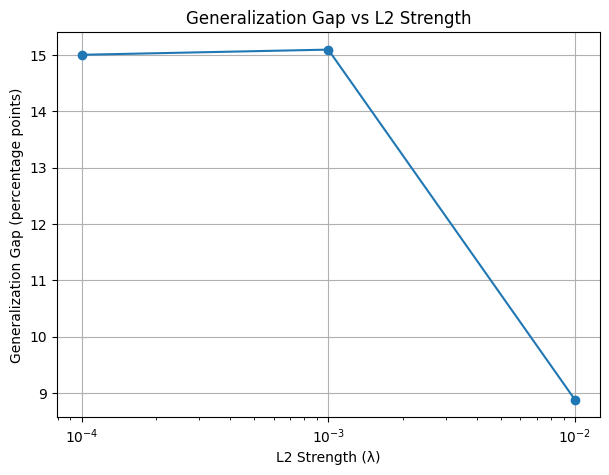

In [95]:
import matplotlib.pyplot as plt

l2_strengths = [result["Setting"] for result in l2_results]
l2_gaps = [result["Gap"] * 100 for result in l2_results]

plt.figure(figsize=(7, 5))

plt.plot(l2_strengths, l2_gaps, marker="o")

plt.xscale("log")
plt.xlabel("L2 Strength (λ)")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap vs L2 Strength")

plt.grid(True)
plt.show()

## **Step 5: L1 Regularization**

In [96]:
def train_model_l1(model, train_loader, val_loader, epochs=50,
               l1_lambda=1e-5):
    
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
    )

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

       
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            l1_penalty = 0

            for name,param in model.named_parameters():
                if "weight" in name:
                    l1_penalty+= torch.sum(torch.abs(param))

            loss = loss + l1_lambda* l1_penalty
            
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_accuracy = correct / total

        model.eval()

        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_loss += loss.item()

                predictions = outputs.argmax(dim=1)

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss = total_loss / len(val_loader)
        val_accuracy = correct / total


        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)


        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy * 100:.2f}%"
        )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

## **Train the L1 Model**

In [97]:
l1_lambda = 1e-5

l1_model = RegularizedModel().to(device)

l1_train_losses, l1_val_losses, l1_train_acc, l1_val_acc = train_model_l1(
    l1_model,
    Overfit_Loader,
    val_Loader,
    epochs=50,
    l1_lambda=l1_lambda
)

Epoch  1/50 | Train Loss: 1.6512 | Train Acc: 44.10% | Val Loss: 0.9832 | Val Acc: 61.75%
Epoch  2/50 | Train Loss: 1.0140 | Train Acc: 65.30% | Val Loss: 0.7468 | Val Acc: 71.52%
Epoch  3/50 | Train Loss: 0.8516 | Train Acc: 73.40% | Val Loss: 0.6886 | Val Acc: 73.85%
Epoch  4/50 | Train Loss: 0.7262 | Train Acc: 77.60% | Val Loss: 0.6021 | Val Acc: 77.03%
Epoch  5/50 | Train Loss: 0.6699 | Train Acc: 80.50% | Val Loss: 0.5771 | Val Acc: 78.53%
Epoch  6/50 | Train Loss: 0.5876 | Train Acc: 83.65% | Val Loss: 0.6664 | Val Acc: 76.68%
Epoch  7/50 | Train Loss: 0.6085 | Train Acc: 82.45% | Val Loss: 0.5395 | Val Acc: 80.67%
Epoch  8/50 | Train Loss: 0.6441 | Train Acc: 82.35% | Val Loss: 0.6676 | Val Acc: 76.07%
Epoch  9/50 | Train Loss: 0.5914 | Train Acc: 83.25% | Val Loss: 0.6028 | Val Acc: 77.85%
Epoch 10/50 | Train Loss: 0.5372 | Train Acc: 85.00% | Val Loss: 0.5827 | Val Acc: 79.07%
Epoch 11/50 | Train Loss: 0.5467 | Train Acc: 84.40% | Val Loss: 0.5286 | Val Acc: 82.00%
Epoch 12/5

## **Percentage of very Small Weights**

In [98]:
weights= []

for name,param in l1_model.named_parameters():
    if "weight" in name:
          weights.append(param.detach().abs().flatten())


weights = torch.cat(weights)
small_weights_percentage = (
    (weights < 1e-3).float().mean().item() * 100
)

print(f"Percentage of weights < 1e-3: {small_weights_percentage:.2f}%")

Percentage of weights < 1e-3: 56.23%


## **Calculate Generalization Gap**

In [99]:
train_acc = l1_train_acc[-1]
val_acc = l1_val_acc [-1]
gap = train_acc - val_acc

print(f"Final Train Accuracy: {train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Generalization Gap: {gap*100:.2f} percentage points")
print(f"Weights < 1e-3: {small_weights_percentage:.2f}%")


Final Train Accuracy: 98.25%
Final Validation Accuracy: 82.61%
Generalization Gap: 15.64 percentage points
Weights < 1e-3: 56.23%


## **Step 6: Dropout Model**

In [100]:
class MyDropoutModel(nn.Module):
    def __init__(self, rate):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.output = nn.Linear(512, 10)

        self.drop = nn.Dropout(rate)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop(x)

        x = torch.relu(self.fc2(x))
        x = self.drop(x)

        x = torch.relu(self.fc3(x))
        x = self.drop(x)

        x = torch.relu(self.fc4(x))
        x = self.drop(x)

        x = self.output(x)

        return x

## **Running Three Dropout Experiments**

In [101]:
dropout_rates = [0.2, 0.4, 0.5]

dropout_results = []

for rate in dropout_rates:

    print(f"\n===== Dropout Rate: {rate} =====")

    model = MyDropoutModel(rate).to(device)

    train_losses, val_losses, train_acc, val_acc = train_model(
        model,
        Overfit_Loader,
        val_Loader,
        epochs=50
    )

    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]
    gap = final_train_acc - final_val_acc

    dropout_results.append({
        "Method": "Dropout",
        "Setting": rate,
        "Train Acc": final_train_acc,
        "Val Acc": final_val_acc,
        "Gap": gap
    })

    print(f"Final Train Accuracy: {final_train_acc*100:.2f}%")
    print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
    print(f"Generalization Gap: {gap*100:.2f} percentage points")


===== Dropout Rate: 0.2 =====
Epoch  1/50 | Train Loss: 1.5512 | Train Acc: 38.25% | Val Loss: 0.9889 | Val Acc: 57.93%
Epoch  2/50 | Train Loss: 0.9384 | Train Acc: 62.05% | Val Loss: 0.7761 | Val Acc: 68.42%
Epoch  3/50 | Train Loss: 0.7537 | Train Acc: 71.70% | Val Loss: 0.7117 | Val Acc: 73.42%
Epoch  4/50 | Train Loss: 0.6182 | Train Acc: 77.45% | Val Loss: 0.6391 | Val Acc: 75.58%
Epoch  5/50 | Train Loss: 0.5655 | Train Acc: 79.05% | Val Loss: 0.5494 | Val Acc: 79.24%
Epoch  6/50 | Train Loss: 0.4937 | Train Acc: 81.55% | Val Loss: 0.5910 | Val Acc: 77.53%
Epoch  7/50 | Train Loss: 0.4689 | Train Acc: 81.60% | Val Loss: 0.6064 | Val Acc: 77.32%
Epoch  8/50 | Train Loss: 0.4809 | Train Acc: 81.10% | Val Loss: 0.7209 | Val Acc: 73.91%
Epoch  9/50 | Train Loss: 0.4878 | Train Acc: 80.60% | Val Loss: 0.5747 | Val Acc: 79.45%
Epoch 10/50 | Train Loss: 0.4401 | Train Acc: 83.20% | Val Loss: 0.5483 | Val Acc: 80.29%
Epoch 11/50 | Train Loss: 0.3907 | Train Acc: 85.00% | Val Loss: 0.54

## **Gap vs Dropout Rate Plot**

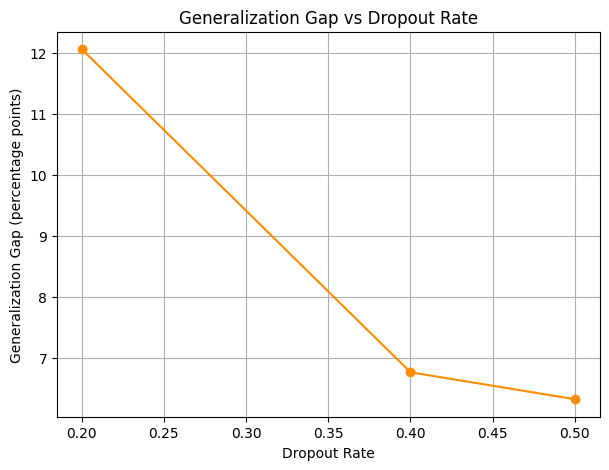

In [102]:
dropout_strengths = [r["Setting"] for r in dropout_results]
dropout_gaps = [r["Gap"] * 100 for r in dropout_results]

plt.figure(figsize=(7, 5))
plt.plot(dropout_strengths, dropout_gaps, marker="o", color="darkorange")
plt.xlabel("Dropout Rate")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap vs Dropout Rate")
plt.grid(True)
plt.show()


## **Step 7 : Batch Normalisation**

In [118]:
class BatchNormModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, 512)
        self.bn3 = nn.BatchNorm1d(512)
        self.fc4 = nn.Linear(512, 512)
        self.bn4 = nn.BatchNorm1d(512)

        self.output = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = torch.relu(self.bn3(self.fc3(x)))
        x = torch.relu(self.bn4(self.fc4(x)))
        x = self.output(x)
        return x


In [119]:
bn_model = BatchNormModel().to(device)

bn_train_losses, bn_val_losses, bn_train_acc, bn_val_acc = train_model(
    bn_model,
    Overfit_Loader,
    val_Loader,
    epochs=50
)

bn_final_train_acc = bn_train_acc[-1]
bn_final_val_acc = bn_val_acc[-1]
bn_gap = bn_final_train_acc - bn_final_val_acc

print(f"Final Train Accuracy: {bn_final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {bn_final_val_acc*100:.2f}%")
print(f"Generalization Gap: {bn_gap*100:.2f} percentage points")


Epoch  1/50 | Train Loss: 0.8168 | Train Acc: 71.40% | Val Loss: 0.6225 | Val Acc: 76.67%
Epoch  2/50 | Train Loss: 0.5126 | Train Acc: 81.55% | Val Loss: 0.5353 | Val Acc: 79.99%
Epoch  3/50 | Train Loss: 0.3660 | Train Acc: 86.60% | Val Loss: 0.5745 | Val Acc: 80.06%
Epoch  4/50 | Train Loss: 0.3648 | Train Acc: 86.65% | Val Loss: 0.6241 | Val Acc: 78.67%
Epoch  5/50 | Train Loss: 0.3242 | Train Acc: 88.55% | Val Loss: 0.6306 | Val Acc: 80.35%
Epoch  6/50 | Train Loss: 0.2921 | Train Acc: 89.85% | Val Loss: 0.5328 | Val Acc: 81.93%
Epoch  7/50 | Train Loss: 0.2452 | Train Acc: 91.30% | Val Loss: 0.6673 | Val Acc: 78.72%
Epoch  8/50 | Train Loss: 0.2131 | Train Acc: 92.55% | Val Loss: 0.6814 | Val Acc: 80.46%
Epoch  9/50 | Train Loss: 0.1913 | Train Acc: 92.50% | Val Loss: 0.7094 | Val Acc: 80.21%
Epoch 10/50 | Train Loss: 0.1755 | Train Acc: 93.65% | Val Loss: 0.7225 | Val Acc: 80.99%
Epoch 11/50 | Train Loss: 0.1526 | Train Acc: 94.90% | Val Loss: 0.8819 | Val Acc: 77.44%
Epoch 12/5

## **Step 8: Early Stopping**

In [120]:
def train_model_early_stopping(model, train_loader, val_loader, epochs=50, patience=5):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_loss = float("inf")
    epochs_no_improve = 0
    stopped_epoch = epochs
    best_state = None

    for epoch in range(epochs):

        model.train()
        total_loss, correct, total = 0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_accuracy = correct / total

        model.eval()
        total_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                total_loss += loss.item()
                predictions = outputs.argmax(dim=1)
                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss = total_loss / len(val_loader)
        val_accuracy = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy*100:.2f}%"
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            stopped_epoch = epoch + 1
            print(f"\nEarly stopping triggered at epoch {stopped_epoch} (patience={patience}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses, train_accuracies, val_accuracies, stopped_epoch


In [121]:
EARLY_STOPPING_PATIENCE = 5
es_model = RegularizedModel().to(device)

es_train_losses, es_val_losses, es_train_acc, es_val_acc, es_stopped_epoch = train_model_early_stopping(
    es_model,
    Overfit_Loader,
    val_Loader,
    epochs=50,
    patience=EARLY_STOPPING_PATIENCE
)

es_final_train_acc = es_train_acc[-1]
es_final_val_acc = es_val_acc[-1]
es_gap = es_final_train_acc - es_final_val_acc

print(f"\nPatience: {EARLY_STOPPING_PATIENCE}")
print(f"Stopped at epoch: {es_stopped_epoch}")
print(f"Final Train Accuracy: {es_final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {es_final_val_acc*100:.2f}%")
print(f"Generalization Gap: {es_gap*100:.2f} percentage points")

Epoch  1/50 | Train Loss: 1.3865 | Train Acc: 48.15% | Val Loss: 0.9395 | Val Acc: 61.67%
Epoch  2/50 | Train Loss: 0.8558 | Train Acc: 65.70% | Val Loss: 0.7740 | Val Acc: 67.42%
Epoch  3/50 | Train Loss: 0.6994 | Train Acc: 73.40% | Val Loss: 0.6621 | Val Acc: 75.64%
Epoch  4/50 | Train Loss: 0.5533 | Train Acc: 78.10% | Val Loss: 0.6488 | Val Acc: 75.53%
Epoch  5/50 | Train Loss: 0.5223 | Train Acc: 79.75% | Val Loss: 0.6491 | Val Acc: 76.01%
Epoch  6/50 | Train Loss: 0.4442 | Train Acc: 84.10% | Val Loss: 0.5893 | Val Acc: 78.54%
Epoch  7/50 | Train Loss: 0.4345 | Train Acc: 83.90% | Val Loss: 0.7159 | Val Acc: 74.04%
Epoch  8/50 | Train Loss: 0.4974 | Train Acc: 81.60% | Val Loss: 0.5877 | Val Acc: 79.97%
Epoch  9/50 | Train Loss: 0.3919 | Train Acc: 85.55% | Val Loss: 0.5402 | Val Acc: 81.46%
Epoch 10/50 | Train Loss: 0.3557 | Train Acc: 87.00% | Val Loss: 0.5895 | Val Acc: 79.72%
Epoch 11/50 | Train Loss: 0.3269 | Train Acc: 87.20% | Val Loss: 0.9080 | Val Acc: 73.90%
Epoch 12/5

## **Step 9 : Data Augmentation ( Random Horizontal Flip + Small  Rotation)**

In [131]:
from torchvision import transforms
from torch.utils.data import Dataset

augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

class AugmentedFashionDataset(Dataset):
    
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].view(1, 28, 28)
        if self.transform:
            image = self.transform(image)
        return image.reshape(-1), self.y[idx]


augmented_dataset = AugmentedFashionDataset(
    X_Overfit_tensor,
    Y_Overfit_tensor,
    transform=augmentation_transform
)

Augmented_Loader = DataLoader(
    augmented_dataset,
    batch_size=64,
    shuffle=True
)


In [132]:
aug_model = RegularizedModel().to(device)
aug_train_losses, aug_val_losses, aug_train_acc, aug_val_acc = train_model(
    aug_model,
    Augmented_Loader,
    val_Loader,
    epochs=50
)

aug_final_train_acc = aug_train_acc[-1]
aug_final_val_acc = aug_val_acc[-1]
aug_gap = aug_final_train_acc - aug_final_val_acc

print(f"Final Train Accuracy: {aug_final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {aug_final_val_acc*100:.2f}%")
print(f"Generalization Gap: {aug_gap*100:.2f} percentage points")


Epoch  1/50 | Train Loss: 1.5736 | Train Acc: 37.00% | Val Loss: 1.1664 | Val Acc: 51.62%
Epoch  2/50 | Train Loss: 1.0071 | Train Acc: 60.20% | Val Loss: 0.8051 | Val Acc: 66.83%
Epoch  3/50 | Train Loss: 0.8165 | Train Acc: 68.70% | Val Loss: 0.7789 | Val Acc: 69.34%
Epoch  4/50 | Train Loss: 0.6979 | Train Acc: 74.10% | Val Loss: 0.6782 | Val Acc: 74.36%
Epoch  5/50 | Train Loss: 0.6198 | Train Acc: 76.85% | Val Loss: 0.6532 | Val Acc: 76.46%
Epoch  6/50 | Train Loss: 0.6208 | Train Acc: 75.95% | Val Loss: 0.6520 | Val Acc: 75.15%
Epoch  7/50 | Train Loss: 0.5567 | Train Acc: 79.35% | Val Loss: 0.6291 | Val Acc: 76.93%
Epoch  8/50 | Train Loss: 0.5660 | Train Acc: 78.10% | Val Loss: 0.6677 | Val Acc: 74.45%
Epoch  9/50 | Train Loss: 0.5662 | Train Acc: 78.50% | Val Loss: 0.5961 | Val Acc: 77.98%
Epoch 10/50 | Train Loss: 0.5446 | Train Acc: 79.45% | Val Loss: 0.5837 | Val Acc: 78.77%
Epoch 11/50 | Train Loss: 0.4917 | Train Acc: 80.80% | Val Loss: 0.5438 | Val Acc: 80.72%
Epoch 12/5

## **Step 10: More Training Data (10,000 and 20,000 samples)**

In [135]:
more_data_results = {}

for n_samples in [10000, 20000]:
    print(f"\n===== Training with {n_samples} samples =====")

    X_more = torch.tensor(X_train[:n_samples], dtype=torch.float32)
    y_more = torch.tensor(y_train[:n_samples], dtype=torch.long)

    more_dataset = TensorDataset(X_more, y_more)
    more_loader = DataLoader(more_dataset, batch_size=64, shuffle=True)

    model = RegularizedModel().to(device)

    train_losses, val_losses, train_acc, val_acc = train_model(
        model,
        more_loader,
        val_Loader,
        epochs=50
    )

    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]
    gap = final_train_acc - final_val_acc

    more_data_results[n_samples] = {
        "Train Acc": final_train_acc,
        "Val Acc": final_val_acc,
        "Gap": gap
    }

    print(f"Final Train Accuracy: {final_train_acc*100:.2f}%")
    print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
    print(f"Generalization Gap: {gap*100:.2f} percentage points")



===== Training with 10000 samples =====
Epoch  1/50 | Train Loss: 0.8469 | Train Acc: 66.99% | Val Loss: 0.5599 | Val Acc: 77.89%
Epoch  2/50 | Train Loss: 0.5267 | Train Acc: 80.53% | Val Loss: 0.5472 | Val Acc: 80.42%
Epoch  3/50 | Train Loss: 0.4608 | Train Acc: 83.51% | Val Loss: 0.4942 | Val Acc: 81.38%
Epoch  4/50 | Train Loss: 0.4085 | Train Acc: 85.22% | Val Loss: 0.4315 | Val Acc: 84.01%
Epoch  5/50 | Train Loss: 0.3714 | Train Acc: 86.10% | Val Loss: 0.4408 | Val Acc: 84.14%
Epoch  6/50 | Train Loss: 0.3658 | Train Acc: 86.72% | Val Loss: 0.4316 | Val Acc: 84.38%
Epoch  7/50 | Train Loss: 0.3361 | Train Acc: 87.63% | Val Loss: 0.4585 | Val Acc: 84.03%
Epoch  8/50 | Train Loss: 0.3246 | Train Acc: 87.96% | Val Loss: 0.4009 | Val Acc: 85.79%
Epoch  9/50 | Train Loss: 0.3008 | Train Acc: 88.76% | Val Loss: 0.4138 | Val Acc: 85.80%
Epoch 10/50 | Train Loss: 0.2992 | Train Acc: 89.23% | Val Loss: 0.4814 | Val Acc: 82.93%
Epoch 11/50 | Train Loss: 0.3002 | Train Acc: 88.89% | Val 

## **Consolidated Regularisation Results Table**

In [137]:
l1_final_train_acc = l1_train_acc[-1]
l1_final_val_acc = l1_val_acc[-1]
l1_gap = l1_final_train_acc - l1_final_val_acc

results_table_rows = []

results_table_rows.append({
    "Method": "Baseline (no regularisation)",
    "Setting": "-",
    "Train accuracy": final_train_accuracy,
    "Validation accuracy": final_val_accuracy,
    "Gap": generalisation_gap
})

for r in l2_results:
    results_table_rows.append({
        "Method": "L2 weight decay",
        "Setting": f"lambda={r['Setting']}",
        "Train accuracy": r["Train Accuracy"],
        "Validation accuracy": r["Validation Accuracy"],
        "Gap": r["Gap"]
    })

results_table_rows.append({
    "Method": "L1 penalty",
    "Setting": f"lambda={l1_lambda} ({small_weights_percentage:.1f}% weights < 1e-3)",
    "Train accuracy": l1_final_train_acc,
    "Validation accuracy": l1_final_val_acc,
    "Gap": l1_gap
})

for r in dropout_results:
    results_table_rows.append({
        "Method": "Dropout",
        "Setting": f"rate={r['Setting']}",
        "Train accuracy": r["Train Acc"],
        "Validation accuracy": r["Val Acc"],
        "Gap": r["Gap"]
    })

results_table_rows.append({
    "Method": "Batch normalisation",
    "Setting": "-",
    "Train accuracy": bn_final_train_acc,
    "Validation accuracy": bn_final_val_acc,
    "Gap": bn_gap
})

results_table_rows.append({
    "Method": "Early stopping",
    "Setting": f"patience={EARLY_STOPPING_PATIENCE}, stopped@epoch={es_stopped_epoch}",
    "Train accuracy": es_final_train_acc,
    "Validation accuracy": es_final_val_acc,
    "Gap": es_gap
})

results_table_rows.append({
    "Method": "Data augmentation",
    "Setting": "H-flip (p=0.5) + rotation(+/-10deg)",
    "Train accuracy": aug_final_train_acc,
    "Validation accuracy": aug_final_val_acc,
    "Gap": aug_gap
})

for n_samples, r in more_data_results.items():
    results_table_rows.append({
        "Method": "More training data",
        "Setting": f"n={n_samples}",
        "Train accuracy": r["Train Acc"],
        "Validation accuracy": r["Val Acc"],
        "Gap": r["Gap"]
    })

results_table = pd.DataFrame(results_table_rows)

results_table_display = results_table.copy()
for col in ["Train accuracy", "Validation accuracy", "Gap"]:
    results_table_display[col] = (results_table_display[col] * 100).round(2)

display(results_table_display)


,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),-,99.15,82.90,16.25
1,L2 weight decay,lambda=0.0001,98.20,83.20,15.00
2,L2 weight decay,lambda=0.001,97.25,82.16,15.09
3,L2 weight decay,lambda=0.01,88.45,79.57,8.88
4,L1 penalty,lambda=1e-05 (56.2% weights < 1e-3),98.25,82.61,15.64
5,Dropout,rate=0.2,95.35,83.29,12.06
6,Dropout,rate=0.4,90.05,83.29,6.76
7,Dropout,rate=0.5,88.00,81.68,6.32
8,Batch normalisation,-,97.95,81.14,16.81
9,Early stopping,"patience=5, stopped@epoch=14",87.95,81.13,6.82


## **Generalisation Gap vs Strength — L2 and Dropout (Side by Side)**

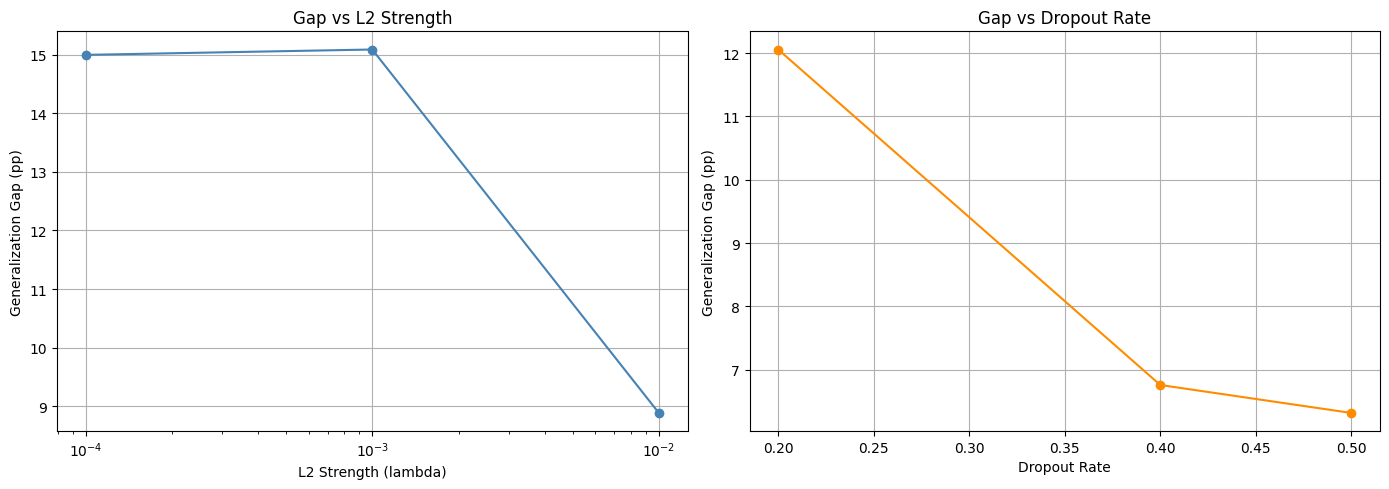

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(l2_strengths, l2_gaps, marker="o", color="steelblue")
axes[0].set_xscale("log")
axes[0].set_xlabel("L2 Strength (lambda)")
axes[0].set_ylabel("Generalization Gap (pp)")
axes[0].set_title("Gap vs L2 Strength")
axes[0].grid(True)

axes[1].plot(dropout_strengths, dropout_gaps, marker="o", color="darkorange")
axes[1].set_xlabel("Dropout Rate")
axes[1].set_ylabel("Generalization Gap (pp)")
axes[1].set_title("Gap vs Dropout Rate")
axes[1].grid(True)

plt.tight_layout()
plt.show()


## **Comparison of Regularisation Methods (<=150 words, generated from the results above)**

In [139]:
methods_summary = [
    {"name": "Baseline", "train": final_train_accuracy, "val": final_val_accuracy, "gap": generalisation_gap},
]

best_l2 = min(l2_results, key=lambda r: r["Gap"])
methods_summary.append({
    "name": f"L2 (lambda={best_l2['Setting']})",
    "train": best_l2["Train Accuracy"], "val": best_l2["Validation Accuracy"], "gap": best_l2["Gap"]
})

methods_summary.append({"name": "L1", "train": l1_final_train_acc, "val": l1_final_val_acc, "gap": l1_gap})

best_dropout = min(dropout_results, key=lambda r: r["Gap"])
methods_summary.append({
    "name": f"Dropout (rate={best_dropout['Setting']})",
    "train": best_dropout["Train Acc"], "val": best_dropout["Val Acc"], "gap": best_dropout["Gap"]
})

methods_summary.append({"name": "Batch normalisation", "train": bn_final_train_acc, "val": bn_final_val_acc, "gap": bn_gap})
methods_summary.append({"name": "Early stopping", "train": es_final_train_acc, "val": es_final_val_acc, "gap": es_gap})
methods_summary.append({"name": "Data augmentation", "train": aug_final_train_acc, "val": aug_final_val_acc, "gap": aug_gap})

baseline_gap = methods_summary[0]["gap"]
baseline_train = methods_summary[0]["train"]

best = None
best_score = None
for m in methods_summary[1:]:
    gap_reduction = baseline_gap - m["gap"]
    train_loss = baseline_train - m["train"]
    score = gap_reduction - train_loss  # reward gap reduction, penalise accuracy loss
    if best_score is None or score > best_score:
        best_score = score
        best = m

best_short_name = best["name"].split(" (")[0]

write_up = (
    f"{best['name']} gave the largest reduction in the generalisation gap for the smallest "
    f"loss in training accuracy, cutting the gap from {baseline_gap*100:.1f}pp to {best['gap']*100:.1f}pp "
    f"while training accuracy moved from {baseline_train*100:.1f}% to {best['train']*100:.1f}%. "
    f"This trade-off was more favourable than the other methods tested, which either reduced the gap "
    f"less or cost more training accuracy for a similar reduction. The gap-vs-strength plots show that "
    f"pushing L2 or dropout too far eventually hurts training accuracy as well, meaning the model starts "
    f"underfitting rather than generalising better. Overall, {best_short_name} offered the "
    f"best balance between reducing overfitting and preserving predictive performance for this network."
)

print(write_up)
print(f"\n[Word count: {len(write_up.split())}]")


Data augmentation gave the largest reduction in the generalisation gap for the smallest loss in training accuracy, cutting the gap from 16.3pp to 6.9pp while training accuracy moved from 99.2% to 90.3%. This trade-off was more favourable than the other methods tested, which either reduced the gap less or cost more training accuracy for a similar reduction. The gap-vs-strength plots show that pushing L2 or dropout too far eventually hurts training accuracy as well, meaning the model starts underfitting rather than generalising better. Overall, Data augmentation offered the best balance between reducing overfitting and preserving predictive performance for this network.

[Word count: 100]


# **Part 7: Hyperparameter Tuning with k-Fold Cross-Validation**



In [140]:
from sklearn.model_selection import KFold
import itertools

In [141]:
search_space = {
    "learning_rate" : [1e-4,5e-4,1e-3,5e-3,1e-2],
    "hidden_width":[128,256,512],
    "dropout_rate":[0.0,0.2,0.3,0.4,0.5]
}
print("Search space:")
for k, v in search_space.items():
    print(f"  {k}: {v}")



Search space:
  learning_rate: [0.0001, 0.0005, 0.001, 0.005, 0.01]
  hidden_width: [128, 256, 512]
  dropout_rate: [0.0, 0.2, 0.3, 0.4, 0.5]


## **Step 2: Sample Random Search Configurations**

In [143]:
random.seed(SEED)
N_CONFIGS = 12

all_combos = list(itertools.product(
    search_space["learning_rate"],
    search_space["hidden_width"],
    search_space["dropout_rate"]
    
))

sampled_combos = random.sample(all_combos,N_CONFIGS)

configs = [
    {"learning_rate" :lr,"hidden_width": hw,"dropout_rate": dr}
    for lr,hw,dr in sampled_combos
    
]

for i,cfg in enumerate(configs,1):
    print(f"Config{i:2d}:{cfg}")

Config 1:{'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.5}
Config 2:{'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.4}
Config 3:{'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.0}
Config 4:{'learning_rate': 0.001, 'hidden_width': 128, 'dropout_rate': 0.2}
Config 5:{'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.4}
Config 6:{'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.3}
Config 7:{'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.4}
Config 8:{'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.2}
Config 9:{'learning_rate': 0.005, 'hidden_width': 256, 'dropout_rate': 0.5}
Config10:{'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.5}
Config11:{'learning_rate': 0.01, 'hidden_width': 512, 'dropout_rate': 0.4}
Config12:{'learning_rate': 0.01, 'hidden_width': 256, 'dropout_rate': 0.3}


## **Step 3: Tunable Model and Single-Fold Training Function**

In [144]:
class TunableModel(nn.Module):
    def __init__(self, hidden_width, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_width)
        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.output = nn.Linear(hidden_width, 10)
        self.drop = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        x = torch.relu(self.fc2(x))
        x = self.drop(x)
        x = self.output(x)
        return x


def train_eval_fold(X_tr, y_tr, X_va, y_va, cfg, epochs=8, batch_size=128):
    model = TunableModel(cfg["hidden_width"], cfg["dropout_rate"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg["learning_rate"])

    tr_dataset = TensorDataset(X_tr, y_tr)
    tr_loader = DataLoader(tr_dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in tr_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_va_dev = X_va.to(device)
        y_va_dev = y_va.to(device)
        predictions = model(X_va_dev).argmax(dim=1)
        accuracy = (predictions == y_va_dev).float().mean().item()

    return accuracy


## **Step 4: Run 5-Fold Cross-Validation over the Random Search**



In [149]:
X_train_full_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_full_tensor = torch.tensor(y_train, dtype=torch.long)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []

for cfg_idx, cfg in enumerate(configs, 1):
    fold_accuracies = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_full_tensor), 1):
        X_tr = X_train_full_tensor[train_idx]
        y_tr = y_train_full_tensor[train_idx]
        X_va = X_train_full_tensor[val_idx]
        y_va = y_train_full_tensor[val_idx]

        acc = train_eval_fold(X_tr, y_tr, X_va, y_va, cfg, epochs=8)
        fold_accuracies.append(acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    cv_results.append({
        "Config": cfg,
        "Mean CV Accuracy": mean_acc,
        "Std CV Accuracy": std_acc
    })

    print(f"Config {cfg_idx:2d}/{N_CONFIGS} {cfg} -> Mean: {mean_acc*100:.2f}% | Std: {std_acc*100:.2f}%")


Config  1/12 {'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.5} -> Mean: 85.83% | Std: 0.33%
Config  2/12 {'learning_rate': 0.0001, 'hidden_width': 128, 'dropout_rate': 0.4} -> Mean: 83.20% | Std: 0.28%
Config  3/12 {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.0} -> Mean: 87.90% | Std: 0.63%
Config  4/12 {'learning_rate': 0.001, 'hidden_width': 128, 'dropout_rate': 0.2} -> Mean: 87.85% | Std: 0.25%
Config  5/12 {'learning_rate': 0.0005, 'hidden_width': 512, 'dropout_rate': 0.4} -> Mean: 87.79% | Std: 0.49%
Config  6/12 {'learning_rate': 0.0005, 'hidden_width': 128, 'dropout_rate': 0.3} -> Mean: 87.23% | Std: 0.31%
Config  7/12 {'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.4} -> Mean: 86.19% | Std: 0.21%
Config  8/12 {'learning_rate': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.2} -> Mean: 86.68% | Std: 0.20%
Config  9/12 {'learning_rate': 0.005, 'hidden_width': 256, 'dropout_rate': 0.5} -> Mean: 83.81% | Std: 1.22%
Config 10/12 

## **Step 5: Top 5 Configurations and Final Selection**

In [150]:
cv_results_sorted = sorted(cv_results, key=lambda r: r["Mean CV Accuracy"], reverse=True)
top5 = cv_results_sorted[:5]

top5_table = pd.DataFrame([
    {
        "Learning rate": r["Config"]["learning_rate"],
        "Hidden width": r["Config"]["hidden_width"],
        "Dropout rate": r["Config"]["dropout_rate"],
        "Mean CV Accuracy": r["Mean CV Accuracy"],
        "Std CV Accuracy": r["Std CV Accuracy"]
    }
    for r in top5
])

display(top5_table)

selected_config = top5[0]["Config"]
print("\nSelected configuration:", selected_config)

,Learning rate,Hidden width,Dropout rate,Mean CV Accuracy,Std CV Accuracy
0,0.0010,256,0.0,0.879000,0.006295
1,0.0010,128,0.2,0.878458,0.002496
2,0.0005,512,0.4,0.877854,0.004855
3,0.0005,128,0.3,0.872271,0.003136
4,0.0001,512,0.2,0.866771,0.001963



Selected configuration: {'learning_rate': 0.001, 'hidden_width': 256, 'dropout_rate': 0.0}


## **Step 6: Identify the Best Regularisation Method from Part 6**

In [151]:
candidate_summaries = [
    {"method": "L2", "setting": max(l2_results, key=lambda r: r["Validation Accuracy"])["Setting"],
     "val_acc": max(l2_results, key=lambda r: r["Validation Accuracy"])["Validation Accuracy"]},
    {"method": "L1", "setting": l1_lambda, "val_acc": l1_final_val_acc},
    {"method": "Dropout", "setting": max(dropout_results, key=lambda r: r["Val Acc"])["Setting"],
     "val_acc": max(dropout_results, key=lambda r: r["Val Acc"])["Val Acc"]},
    {"method": "BatchNorm", "setting": "-", "val_acc": bn_final_val_acc},
    {"method": "EarlyStopping", "setting": EARLY_STOPPING_PATIENCE, "val_acc": es_final_val_acc},
    {"method": "Augmentation", "setting": "-", "val_acc": aug_final_val_acc},
]

best_regulariser = max(candidate_summaries, key=lambda c: c["val_acc"])
print("Best-performing regularisation method from Part 6:", best_regulariser)


Best-performing regularisation method from Part 6: {'method': 'Augmentation', 'setting': '-', 'val_acc': 0.835}


## **Step 7: Retrain the Selected Configuration on the Full Training Set**

In [152]:
weight_decay_final = 0.0
use_augmentation = False
use_early_stopping = False
patience_final = EARLY_STOPPING_PATIENCE

if best_regulariser["method"] == "L2":
    weight_decay_final = best_regulariser["setting"]
elif best_regulariser["method"] == "Augmentation":
    use_augmentation = True
elif best_regulariser["method"] == "EarlyStopping":
    use_early_stopping = True

print(f"Final training config -> lr={selected_config['learning_rate']}, "
      f"hidden_width={selected_config['hidden_width']}, dropout={selected_config['dropout_rate']}, "
      f"weight_decay={weight_decay_final}, augmentation={use_augmentation}, early_stopping={use_early_stopping}")

if use_augmentation:
    final_train_dataset = AugmentedFashionDataset(
        X_train_full_tensor, y_train_full_tensor, transform=augmentation_transform
    )
else:
    final_train_dataset = TensorDataset(X_train_full_tensor, y_train_full_tensor)

final_train_loader = DataLoader(final_train_dataset, batch_size=128, shuffle=True)

X_val_full_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_full_tensor = torch.tensor(y_val, dtype=torch.long)
final_val_dataset = TensorDataset(X_val_full_tensor, y_val_full_tensor)
final_val_loader = DataLoader(final_val_dataset, batch_size=128, shuffle=False)

final_model = TunableModel(selected_config["hidden_width"], selected_config["dropout_rate"]).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=selected_config["learning_rate"], weight_decay=weight_decay_final)
final_criterion = nn.CrossEntropyLoss()

FINAL_EPOCHS = 30
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None
stopped_epoch = FINAL_EPOCHS

for epoch in range(FINAL_EPOCHS):

    final_model.train()
    for X_batch, y_batch in final_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        final_optimizer.zero_grad()
        loss = final_criterion(final_model(X_batch), y_batch)
        loss.backward()
        final_optimizer.step()

    final_model.eval()
    val_loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in final_val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = final_model(X_batch)
            val_loss_total += final_criterion(outputs, y_batch).item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = val_loss_total / len(final_val_loader)
    val_acc = correct / total

    print(f"Epoch {epoch + 1:2d}/{FINAL_EPOCHS} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    if use_early_stopping:
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.clone() for k, v in final_model.state_dict().items()}
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience_final:
            stopped_epoch = epoch + 1
            print(f"Early stopping at epoch {stopped_epoch}")
            break

if use_early_stopping and best_state is not None:
    final_model.load_state_dict(best_state)


Final training config -> lr=0.001, hidden_width=256, dropout=0.0, weight_decay=0.0, augmentation=True, early_stopping=False
Epoch  1/30 | Val Loss: 0.4696 | Val Acc: 83.01%
Epoch  2/30 | Val Loss: 0.4198 | Val Acc: 84.33%
Epoch  3/30 | Val Loss: 0.3931 | Val Acc: 85.22%
Epoch  4/30 | Val Loss: 0.3636 | Val Acc: 86.63%
Epoch  5/30 | Val Loss: 0.3649 | Val Acc: 86.31%
Epoch  6/30 | Val Loss: 0.3472 | Val Acc: 87.23%
Epoch  7/30 | Val Loss: 0.3410 | Val Acc: 87.45%
Epoch  8/30 | Val Loss: 0.3457 | Val Acc: 87.21%
Epoch  9/30 | Val Loss: 0.3487 | Val Acc: 86.86%
Epoch 10/30 | Val Loss: 0.3411 | Val Acc: 87.57%
Epoch 11/30 | Val Loss: 0.3471 | Val Acc: 87.04%
Epoch 12/30 | Val Loss: 0.3155 | Val Acc: 88.18%
Epoch 13/30 | Val Loss: 0.3181 | Val Acc: 88.37%
Epoch 14/30 | Val Loss: 0.3314 | Val Acc: 87.84%
Epoch 15/30 | Val Loss: 0.3201 | Val Acc: 88.29%
Epoch 16/30 | Val Loss: 0.3199 | Val Acc: 88.37%
Epoch 17/30 | Val Loss: 0.3125 | Val Acc: 88.66%
Epoch 18/30 | Val Loss: 0.3076 | Val Acc: 8

## **Step 8: Final Evaluation on the Held-Out Test Set**

In [153]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

final_model.eval()
with torch.no_grad():
    test_outputs = final_model(X_test_tensor)
    test_predictions = test_outputs.argmax(dim=1).cpu().numpy()

y_test_np = y_test_tensor.cpu().numpy()

test_accuracy = accuracy_score(y_test_np, test_predictions)
test_precision_macro = precision_score(y_test_np, test_predictions, average="macro")
test_recall_macro = recall_score(y_test_np, test_predictions, average="macro")
test_f1_macro = f1_score(y_test_np, test_predictions, average="macro")
test_conf_matrix = confusion_matrix(y_test_np, test_predictions)

print(f"Test Accuracy       : {test_accuracy*100:.2f}%")
print(f"Macro Precision     : {test_precision_macro*100:.2f}%")
print(f"Macro Recall        : {test_recall_macro*100:.2f}%")
print(f"Macro F1            : {test_f1_macro*100:.2f}%")


Test Accuracy       : 89.06%
Macro Precision     : 89.21%
Macro Recall        : 89.06%
Macro F1            : 88.97%


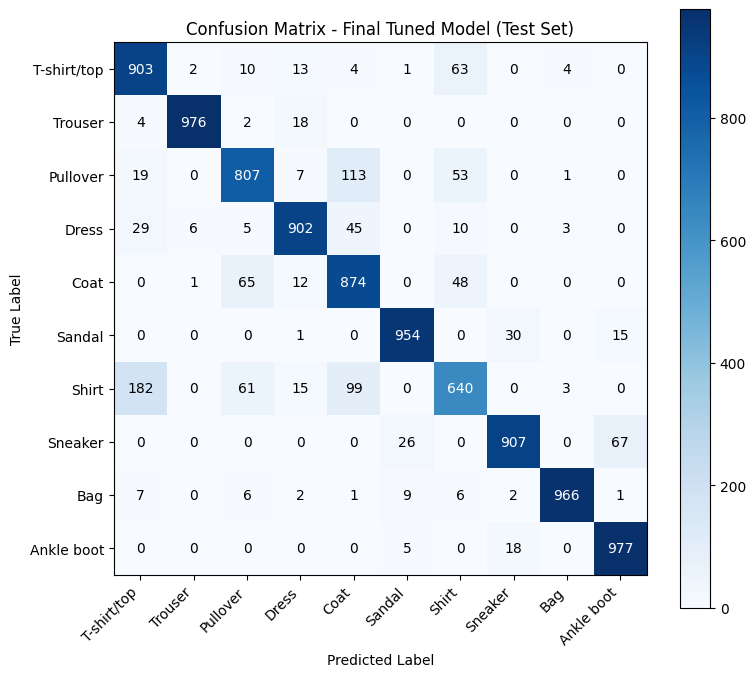

In [154]:
plt.figure(figsize=(8, 7))
plt.imshow(test_conf_matrix, cmap="Blues")
plt.title("Confusion Matrix - Final Tuned Model (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)

for i in range(10):
    for j in range(10):
        plt.text(
            j, i, test_conf_matrix[i, j],
            ha="center", va="center",
            color="white" if test_conf_matrix[i, j] > test_conf_matrix.max() / 2 else "black"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


## **Step 9: Comparison with the Part 2 Baseline**

In [158]:
relu_model.eval()
with torch.no_grad():
    baseline_test_outputs = relu_model(X_test_tensor)
    baseline_test_predictions = baseline_test_outputs.argmax(dim=1).cpu().numpy()

baseline_test_accuracy = accuracy_score(y_test_np, baseline_test_predictions)

improvement_pp = (test_accuracy - baseline_test_accuracy) * 100

print(f"Part 2 baseline (ReLU model) test accuracy : {baseline_test_accuracy*100:.2f}%")
print(f"Part 7 tuned model test accuracy            : {test_accuracy*100:.2f}%")
print(f"Improvement                                 : {improvement_pp:+.2f} percentage points")

if improvement_pp > 0:
    verdict = f"The tuned model improved over the Part 2 baseline by {improvement_pp:.2f} percentage points."
else:
    verdict = (
        f"The tuned model did NOT improve over the Part 2 baseline "
        f"(change of {improvement_pp:.2f} percentage points). This can happen when the Part 2 baseline "
        f"was already close to what a simple fully-connected network can achieve on Fashion-MNIST, and/or "
        f"when the added regularisation trades some training flexibility for lower variance without a "
        f"corresponding gain in test accuracy. It is an honest result, not a failure of the pipeline."
    )

print("\n" + verdict)


Part 2 baseline (ReLU model) test accuracy : 88.26%
Part 7 tuned model test accuracy            : 89.06%
Improvement                                 : +0.80 percentage points

The tuned model improved over the Part 2 baseline by 0.80 percentage points.
